In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

train = pd.read_csv('/kaggle/input/competitions/credit-safe-predicting-loan-default-risk2/cs-training (1).csv')
test = pd.read_csv('/kaggle/input/competitions/credit-safe-predicting-loan-default-risk2/cs-test (1).csv')

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)

display(train.head())

Training set shape: (112500, 12)
Test set shape: (37500, 11)


,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,140301,0.034949,60,0,0.004933,8311.0,5,0,0,0,0.0,0
1,92418,0.155308,46,0,881.000000,NaN,6,0,1,0,0.0,0
2,48194,0.165166,63,1,0.020327,3000.0,8,0,0,0,0.0,0
3,66645,0.010886,60,0,0.642979,1167.0,6,0,1,0,0.0,0
4,144735,0.000717,48,0,3603.000000,NaN,15,0,3,0,0.0,0


# 1. Exploratory Data Analysis

<Figure size 1200x600 with 0 Axes>

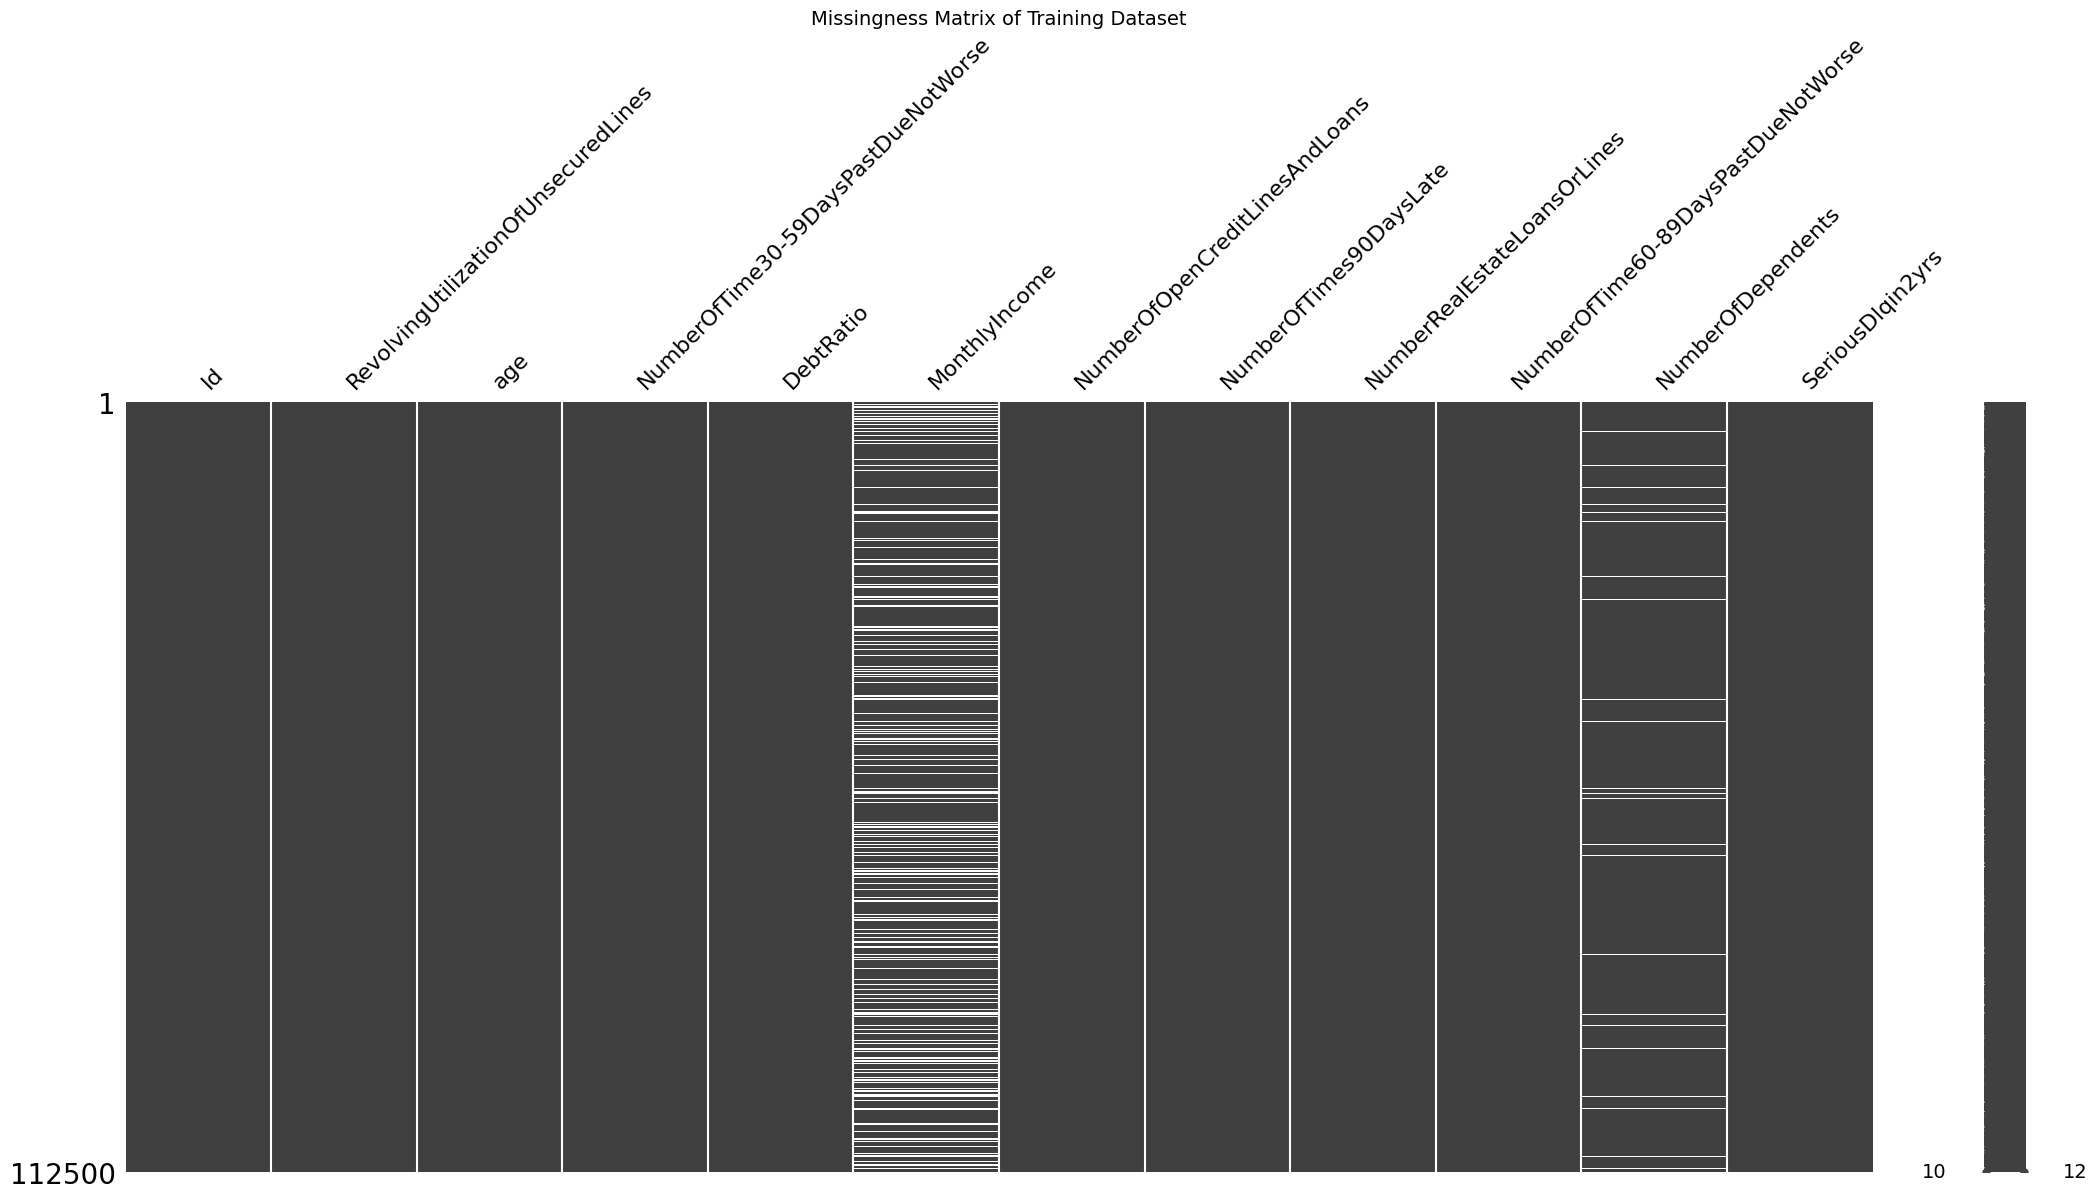

In [2]:
# 1. Missingness Audit

# missingno matrix
plt.figure(figsize=(12,6))
msno.matrix(train)
plt.title('Missingness Matrix of Training Dataset', fontsize=14)
plt.show()

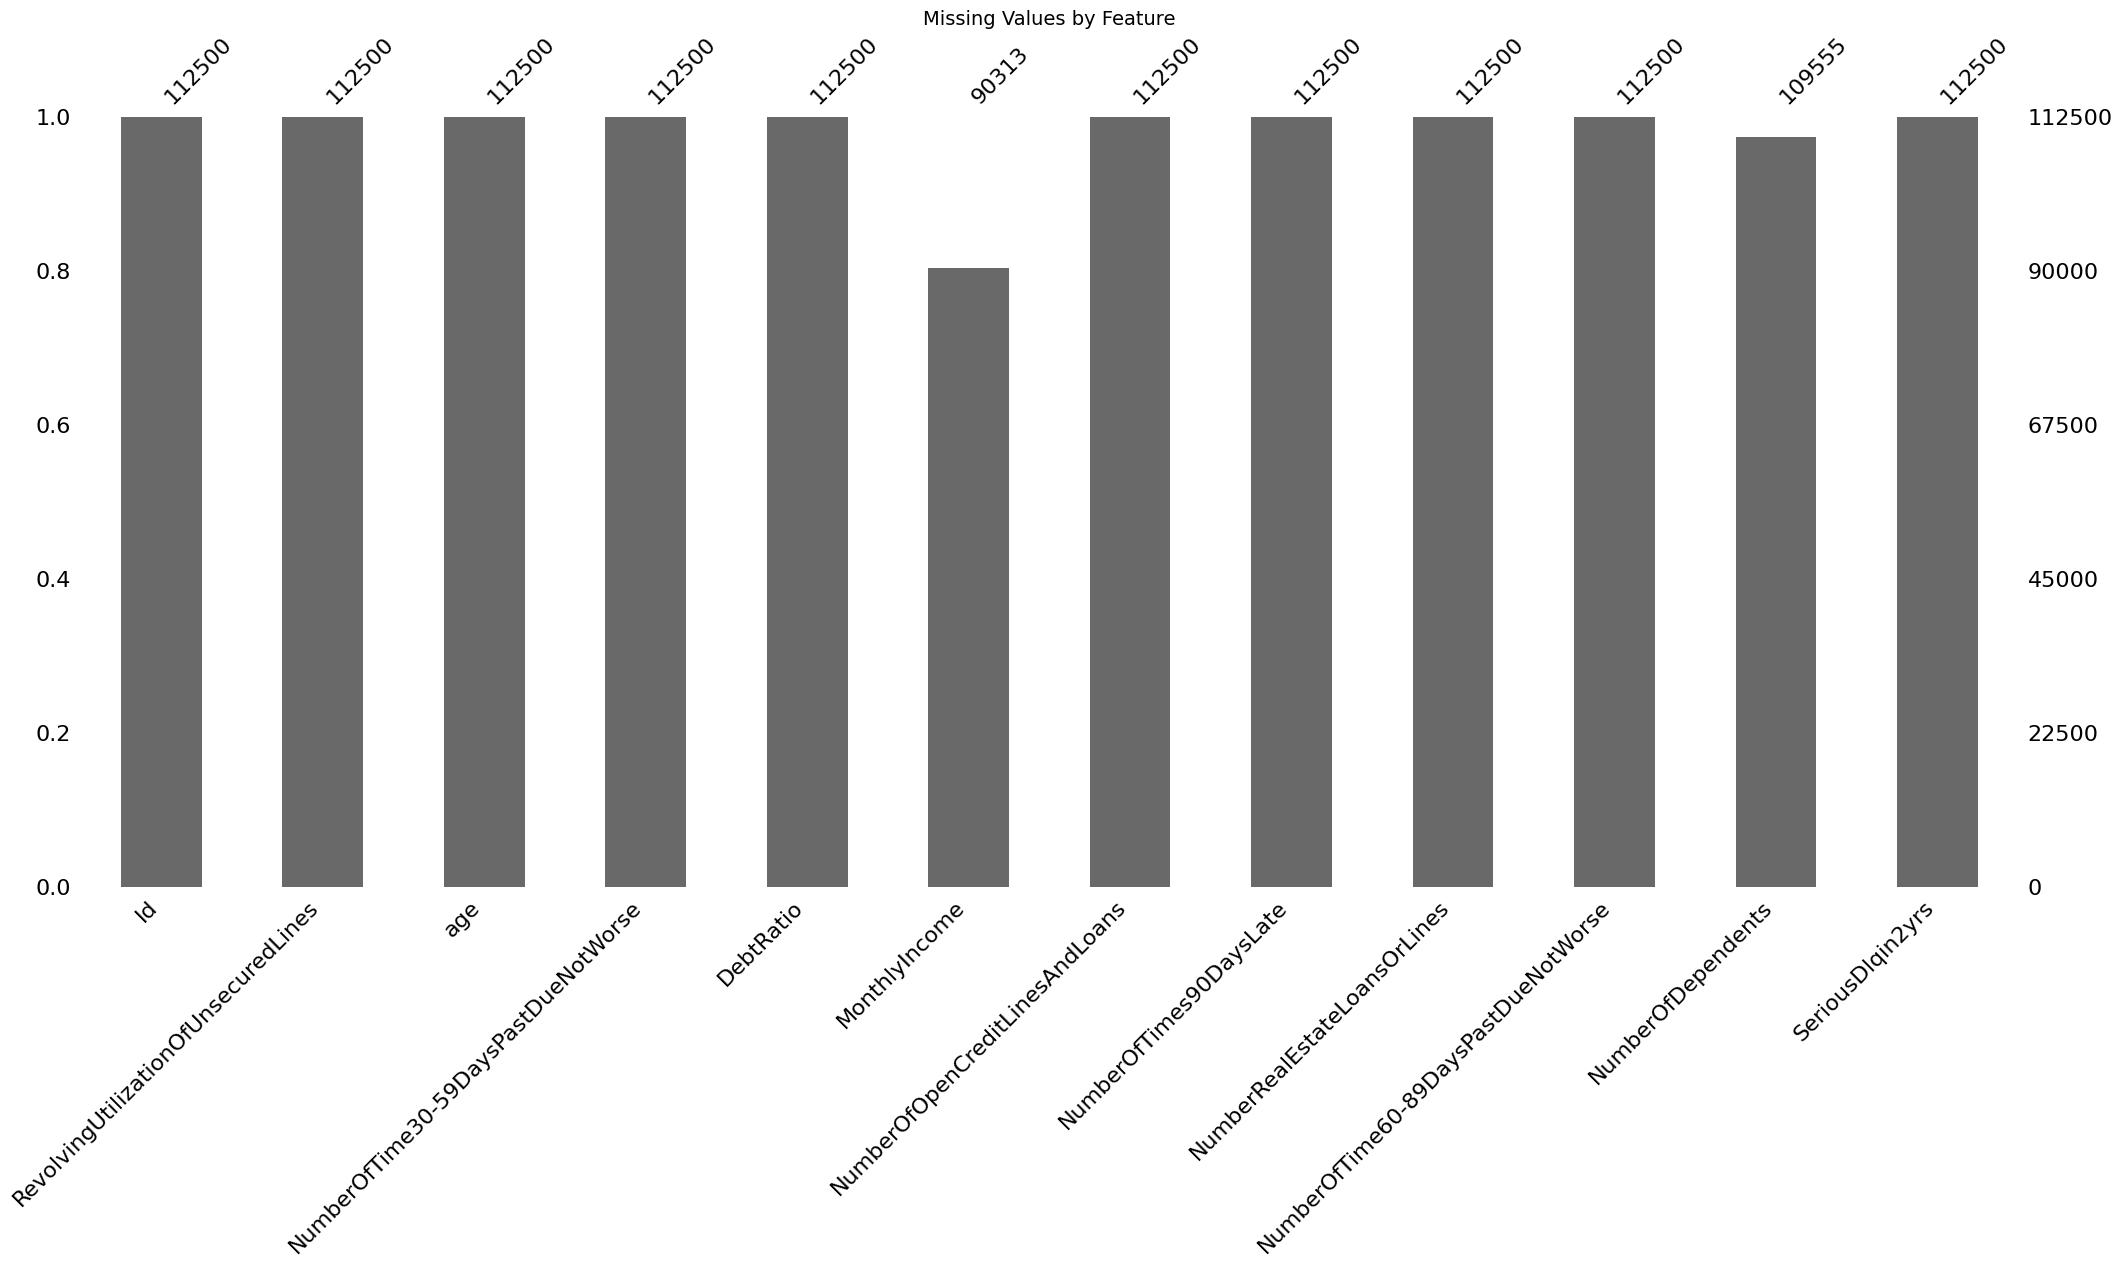

In [3]:
# missingno bar chart
plt.figure(figsize=(10,5))
msno.bar(train)
plt.title('Missing Values by Feature', fontsize=14)
plt.show()

In [4]:
# Missing counts and percentages for all features
missing_counts = train.isnull().sum()
missing_percentages = (
    train.isnull().mean() * 100
).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})
missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)
display(missing_summary)

,Missing Count,Missing Percentage
MonthlyIncome,22187,19.72
NumberOfDependents,2945,2.62
Id,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
age,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
DebtRatio,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


In [5]:
# Classification of MonthlyIncome missingness and Justification
income_missing_analysis = train.groupby(
    train['MonthlyIncome'].isnull()
)['SeriousDlqin2yrs'].agg(['count', 'mean'])
income_missing_analysis.index = [
    'MonthlyIncome Available',
    'MonthlyIncome Missing'
]
income_missing_analysis.columns = [
    'Number of Borrowers',
    'Default Rate'
]
display(income_missing_analysis)

,Number of Borrowers,Default Rate
MonthlyIncome Available,90313,0.069658
MonthlyIncome Missing,22187,0.055393


### Classification of MonthlyIncome Missingness

The missingness mechanism for MonthlyIncome is classified as `MAR (Missing At Random)`.

### Justification

The missingness mechanism for MonthlyIncome is unlikely to be MCAR because the target distribution differs between observations with missing and non-missing income values. Specifically, borrowers with missing MonthlyIncome exhibit a default rate of approximately 5.54%, compared to 6.97% among borrowers with observed income values. This indicates that the probability of missingness is associated with observed variables related to repayment behaviour.

The mechanism is more appropriately classified as MAR, where missingness depends on observed borrower characteristics available within the dataset. Although MNAR cannot be definitively excluded without access to the true unobserved income values, there is insufficient evidence to conclude that missingness is directly driven by the latent income variable itself. Therefore, MAR represents the most statistically defensible assumption for subsequent imputation and modelling.

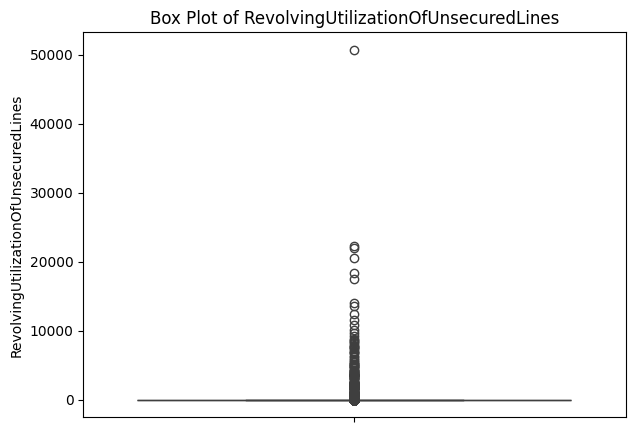

In [6]:
# 2. Outlier Detection

# Box Plot for RevolvingUtilization
plt.figure(figsize=(7, 5))
sns.boxplot(
    y=train['RevolvingUtilizationOfUnsecuredLines']
)
plt.title(
    'Box Plot of RevolvingUtilizationOfUnsecuredLines',
    fontsize=12
)
plt.ylabel(
    'RevolvingUtilizationOfUnsecuredLines'
)
plt.show()

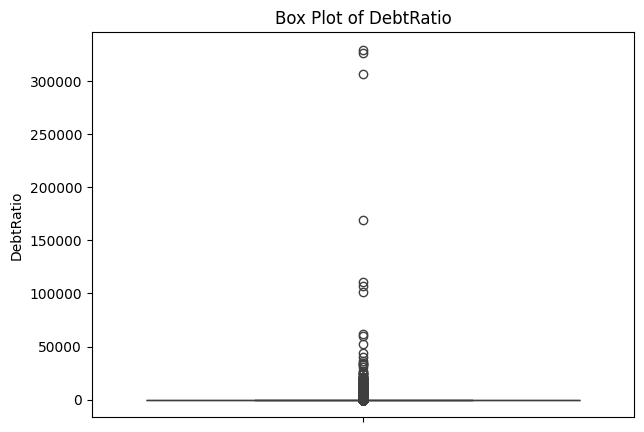

In [7]:
# Box Plot for DebtRatio
plt.figure(figsize=(7, 5))
sns.boxplot(
    y=train['DebtRatio']
)
plt.title(
    'Box Plot of DebtRatio',
    fontsize=12
)
plt.ylabel('DebtRatio')
plt.show()

In [8]:
# IQR-based outlier count for all continuous features
continuous_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome'
]
outlier_summary = []

for feature in continuous_features:    
    q1 = train[feature].quantile(0.25)
    q3 = train[feature].quantile(0.75)    
    iqr = q3 - q1    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)    
    outlier_count = train[
        (train[feature] < lower_bound) |
        (train[feature] > upper_bound)
    ].shape[0]       
    outlier_summary.append({
        'Feature': feature,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
    })
    
outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outlier Count
0,RevolvingUtilizationOfUnsecuredLines,-0.763263,1.351246,591
1,age,8.000000,96.000000,36
2,DebtRatio,-0.848733,1.881430,23342
3,MonthlyIncome,-3863.000000,15505.000000,3688


In [9]:
# Identify and document the sentinel value 98 in NumberOfTime30-
# 59DaysPastDueNotWorse and NumberOfTimes90DaysLate
sentinel_30_59 = (
    train['NumberOfTime30-59DaysPastDueNotWorse'] == 98
).sum()
sentinel_90 = (
    train['NumberOfTimes90DaysLate'] == 98
).sum()
print(
    "Sentinel value count in NumberOfTime30-59DaysPastDueNotWorse:",
    sentinel_30_59
)
print(
    "Sentinel value count in NumberOfTimes90DaysLate:",
    sentinel_90
)

Sentinel value count in NumberOfTime30-59DaysPastDueNotWorse: 201
Sentinel value count in NumberOfTimes90DaysLate: 201


### Sentinel Value 98 Identification and Documentation

Both NumberOfTime30-59DaysPastDueNotWorse and NumberOfTimes90DaysLate contain 201 observations with a value of 98. Given the financial context of the dataset, a borrower being delinquent exactly 98 times is highly implausible. This strongly suggests that 98 represents a sentinel value used to encode anomalous, undefined, or unavailable delinquency information rather than a legitimate behavioural count.


### Interpretation and Planned Treatment of Sentinal Value 98

The sentinel value 98 most likely represents a placeholder code for missing, corrupted, or non-standard delinquency information rather than a true delinquency frequency. In consumer credit datasets, extremely large repeated delinquency counts are typically administrative encodings introduced during data collection or system migration processes.

Treating these observations as genuine repayment behaviour would artificially distort the feature distributions and introduce severe bias into downstream statistical analysis and model training. Therefore, the sentinel value 98 will be treated as invalid data.

During preprocessing, these values will be `replaced with NaN` and subsequently imputed using an appropriate strategy. This approach preserves the affected observations while preventing the model from interpreting the sentinel code as a legitimate quantitative delinquency count.


,Count,Percentage
SeriousDlqin2yrs,,
0,104980,93.32
1,7520,6.68


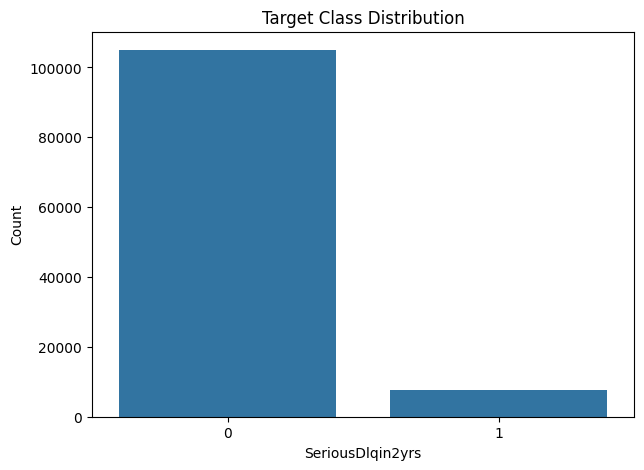

In [10]:
# 3. Class Imbalance Analysis

# Plot of the target distribution (SeriousDlqin2yrs counts and percentages)
target_counts = train['SeriousDlqin2yrs'].value_counts()
target_percentages = (
    train['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
).round(2)
class_distribution = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percentages
})
display(class_distribution)

plt.figure(figsize=(7, 5))
sns.countplot(
    x='SeriousDlqin2yrs',
    data=train
)
plt.title(
    'Target Class Distribution',
    fontsize=12
)
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Count')
plt.show()

In [11]:
# Exact default rate
default_rate = (
    train['SeriousDlqin2yrs'].mean() * 100
)
print(
    f"Exact default rate: {default_rate:.2f}%"
)

Exact default rate: 6.68%


In [12]:
# Naive All-Zero Classifier Accuracy 
naive_accuracy = (
    (train['SeriousDlqin2yrs'] == 0).mean() * 100
)
print(
    f"Accuracy of naive all-zero classifier: {naive_accuracy:.2f}%"
)

Accuracy of naive all-zero classifier: 93.32%


### Misleading Nature of Naive All-Zero Classifier Accuracy

A naive classifier that predicts every borrower as non-default (0) achieves an accuracy of approximately 93.32%. Despite appearing highly accurate, this result is misleading because the dataset is severely class imbalanced, with only 6.68% positive default cases.

The classifier completely fails to identify actual defaults and therefore has zero recall for the minority class. In a credit-risk setting, such a model would be operationally useless because it would approve high-risk borrowers while still reporting deceptively high overall accuracy.

This imbalance demonstrates why accuracy alone is an inappropriate evaluation metric for this problem. Metrics such as ROC-AUC, precision, recall, macro-F1, and precision-recall analysis are more suitable for evaluating predictive performance under severe class imbalance.


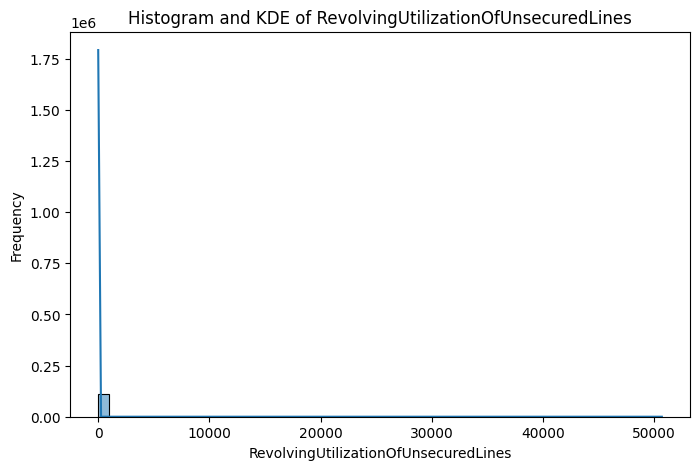

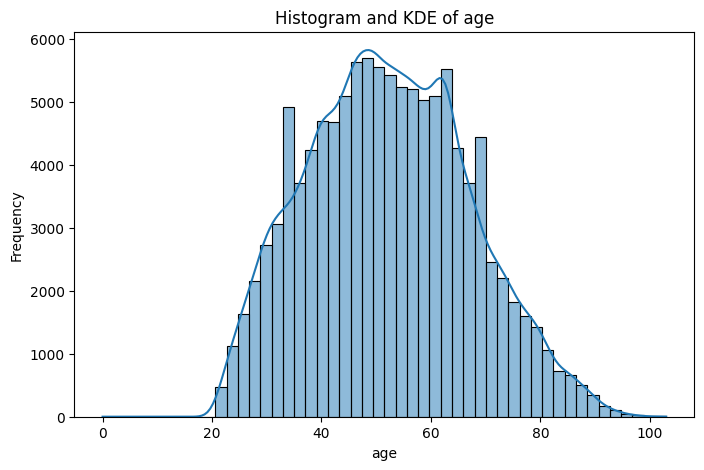

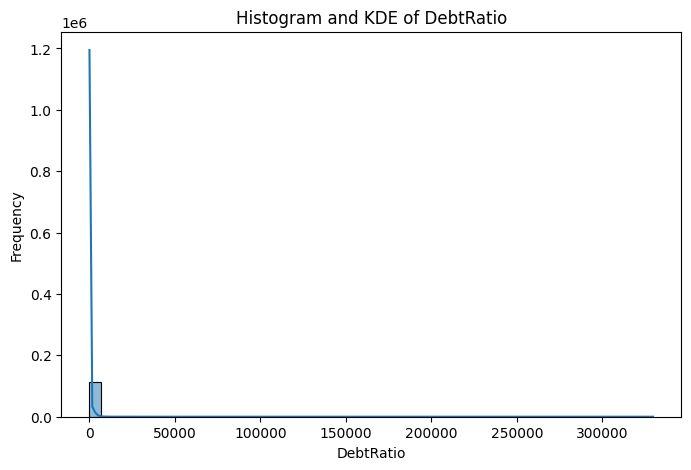

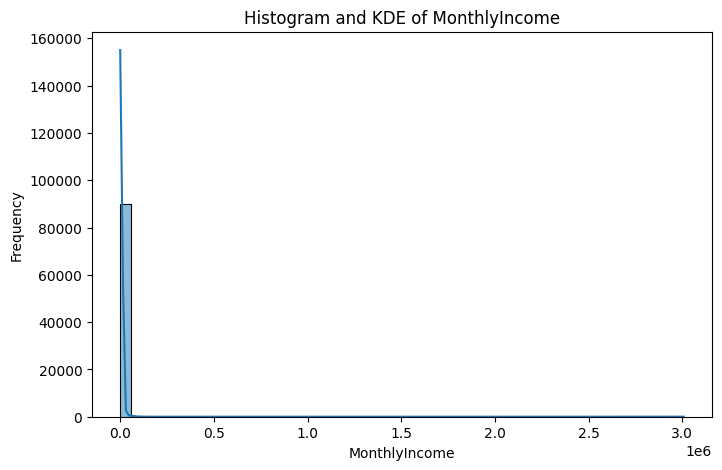

In [13]:
# 4. Univariate Analysis

# Histogram + KDE for all continuous features
continuous_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome'
]
for feature in continuous_features:    
    plt.figure(figsize=(8, 5))    
    sns.histplot(
        train[feature],
        kde=True,
        bins=50
    )    
    plt.title(
        f'Histogram and KDE of {feature}',
        fontsize=12
    )    
    plt.xlabel(feature)    
    plt.ylabel('Frequency')    
    plt.show()

### Right-Skewness Assessment

RevolvingUtilizationOfUnsecuredLines, DebtRatio, and MonthlyIncome exhibit severe positive skewness characterised by long right tails and extreme upper-end outliers. The majority of observations are concentrated near lower values, while a relatively small number of observations extend to exceptionally large magnitudes.

age displays a substantially more symmetric distribution with only mild positive skewness and does not exhibit the same degree of tail extremity observed in the other continuous variables.


### Assessment of Log Transformation Suitability

A log transformation would be appropriate for RevolvingUtilizationOfUnsecuredLines, DebtRatio, and MonthlyIncome due to their substantial positive skewness and extreme upper-tail outliers. Applying a logarithmic transformation would compress the influence of extreme values, reduce distributional asymmetry, and improve numerical stability for models sensitive to feature scale and distributional shape, particularly Logistic Regression.

For RevolvingUtilizationOfUnsecuredLines and DebtRatio, log-based transformation may also improve interpretability by reducing the disproportionate influence of anomalously large financial ratios.

MonthlyIncome is particularly suitable for log transformation because income variables in financial datasets commonly follow heavily right-skewed distributions.

In contrast, a log transformation is not necessary for age because its distribution is comparatively symmetric and does not exhibit severe tail behaviour.


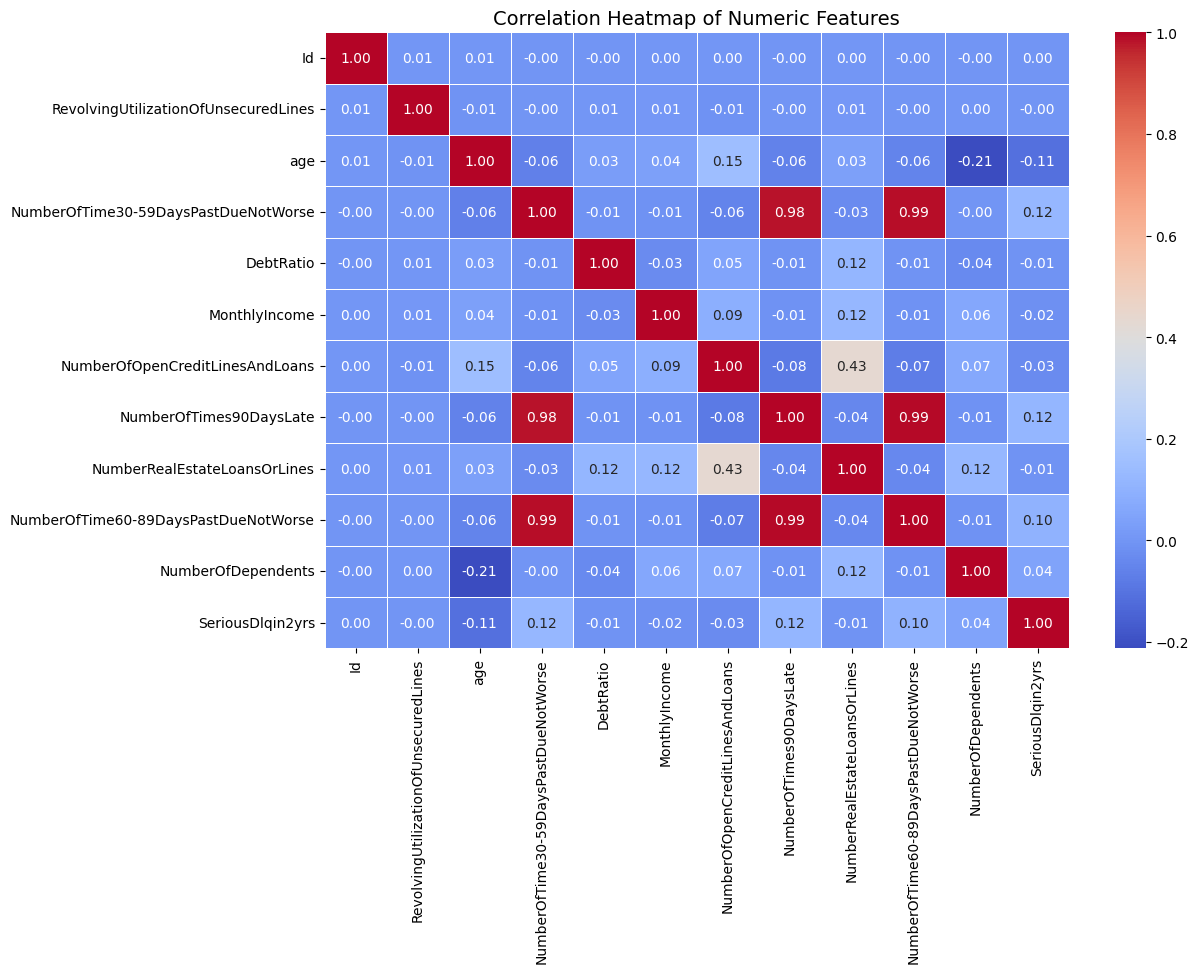

In [14]:
# 5. Bivariate Analysis

# Correlation heatmap for all numeric features
numeric_features = train.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_features.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title(
    'Correlation Heatmap of Numeric Features',
    fontsize=14
)
plt.show()

In [15]:
# Mean default rate for each feature when feature value is high vs low
numeric_features = [
    column for column in train.columns
    if column != 'SeriousDlqin2yrs'
]
default_rate_comparison = []

for feature in numeric_features:
    median_value = train[feature].median()
    low_group = train[
        train[feature] <= median_value
    ]['SeriousDlqin2yrs'].mean()
    high_group = train[
        train[feature] > median_value
    ]['SeriousDlqin2yrs'].mean()
    default_rate_comparison.append({
        'Feature': feature,
        'Median Threshold': median_value,
        'Mean Default Rate (Low Group)': round(low_group * 100, 2),
        'Mean Default Rate (High Group)': round(high_group * 100, 2)
    })

default_rate_comparison = pd.DataFrame(
    default_rate_comparison
)
display(default_rate_comparison)

,Feature,Median Threshold,Mean Default Rate (Low Group),Mean Default Rate (High Group)
0,Id,74835.000000,6.74,6.63
1,RevolvingUtilizationOfUnsecuredLines,0.153517,1.93,11.44
2,age,52.000000,9.06,4.15
3,NumberOfTime30-59DaysPastDueNotWorse,0.000000,4.04,20.56
4,DebtRatio,0.366299,5.88,7.49
5,MonthlyIncome,5400.000000,8.53,5.38
6,NumberOfOpenCreditLinesAndLoans,8.000000,7.04,6.20
7,NumberOfTimes90DaysLate,0.000000,4.61,41.63
8,NumberRealEstateLoansOrLines,1.000000,6.82,6.33
9,NumberOfTime60-89DaysPastDueNotWorse,0.000000,5.09,36.42


In [16]:
# Identify the top 3 features most predictive of default
default_rate_comparison['Risk Ratio'] = (
    default_rate_comparison['Mean Default Rate (High Group)'] /
    default_rate_comparison['Mean Default Rate (Low Group)']
).round(2)
top_predictive_features = default_rate_comparison.sort_values(
    by='Risk Ratio',
    ascending=False
)
display(
    top_predictive_features[
        [
            'Feature',
            'Mean Default Rate (Low Group)',
            'Mean Default Rate (High Group)',
            'Risk Ratio'
        ]
    ].head(3)
)

,Feature,Mean Default Rate (Low Group),Mean Default Rate (High Group),Risk Ratio
7,NumberOfTimes90DaysLate,4.61,41.63,9.03
9,NumberOfTime60-89DaysPastDueNotWorse,5.09,36.42,7.16
1,RevolvingUtilizationOfUnsecuredLines,1.93,11.44,5.93


### EDA-Based Identification of Top 3 Predictive Features

The top 3 features most predictive of default risk based on EDA alone are:

* NumberOfTimes90DaysLate
* NumberOfTime60-89DaysPastDueNotWorse
* RevolvingUtilizationOfUnsecuredLines

These features were identified using the ratio of mean default rate in the high-value group relative to the low-value group after splitting each feature at its median value. Features with larger high-to-low default-rate ratios demonstrated stronger discriminatory power for distinguishing defaulting and non-defaulting borrowers prior to model training.

In [17]:
# 6. Statistical Tests

# Mann-Whitney U test for each continuous feature vs SeriousDlqin2yrs

continuous_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome'
]
mannwhitney_results = []

for feature in continuous_features:
    default_group = train[
        train['SeriousDlqin2yrs'] == 1
    ][feature].dropna()
    non_default_group = train[
        train['SeriousDlqin2yrs'] == 0
    ][feature].dropna()
    statistic, p_value = stats.mannwhitneyu(
        default_group,
        non_default_group,
        alternative='two-sided'
    )
    mannwhitney_results.append({
        'Feature': feature,
        'Mann-Whitney U Statistic': statistic
    })

mannwhitney_results = pd.DataFrame(
    mannwhitney_results
)
display(mannwhitney_results)

,Feature,Mann-Whitney U Statistic
0,RevolvingUtilizationOfUnsecuredLines,613816116.5
1,age,291662703.5
2,DebtRatio,413120201.0
3,MonthlyIncome,224943141.5


In [18]:
# Chi-squared test for NumberOfDependents vs SeriousDlqin2yrs
contingency_table = pd.crosstab(
    train['NumberOfDependents'],
    train['SeriousDlqin2yrs']
)
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)
chi_squared_results = pd.DataFrame({
    'Chi-Squared Statistic': [chi2_statistic],
    'Degrees of Freedom': [dof]
})
display(chi_squared_results)

,Chi-Squared Statistic,Degrees of Freedom
0,234.715069,11


In [19]:
# p-values for Mann-Whitney U test
for index, row in mannwhitney_results.iterrows():
    feature = row['Feature']
    default_group = train[
        train['SeriousDlqin2yrs'] == 1
    ][feature].dropna()
    non_default_group = train[
        train['SeriousDlqin2yrs'] == 0
    ][feature].dropna()
    statistic, p_value = stats.mannwhitneyu(
        default_group,
        non_default_group,
        alternative='two-sided'
    )
    print(f"{feature} p-value: {p_value:.6e}")

RevolvingUtilizationOfUnsecuredLines p-value: 0.000000e+00
age p-value: 0.000000e+00
DebtRatio p-value: 1.362597e-11
MonthlyIncome p-value: 1.233244e-86


In [20]:
# p-values for Chi-squared test
print(f"Chi-squared test p-value: {p_value:.6e}")

Chi-squared test p-value: 1.233244e-86


### Statistical Significance Assessment at α = 0.01

All tested features are statistically significant at the 0.01 significance level because their associated p-values are substantially smaller than the threshold α = 0.01.

The Mann-Whitney U tests indicate statistically significant distributional differences between default and non-default borrowers for all continuous variables:

* RevolvingUtilizationOfUnsecuredLines
* age
* DebtRatio
* MonthlyIncome

Similarly, the chi-squared test indicates a statistically significant association between NumberOfDependents and SeriousDlqin2yrs.

Therefore, the null hypotheses of equal distributions and independence are rejected for all tested variables at the 1% significance level.


### EDA Summary

The exploratory data analysis identified multiple dataset-specific data-quality issues that require careful preprocessing before model development. MonthlyIncome contained 22,187 missing values, representing approximately 19.72% of the training dataset, while NumberOfDependents contained 2,945 missing observations corresponding to approximately 2.62% of rows. The default rate differed between borrowers with missing and non-missing MonthlyIncome values, suggesting that the missingness mechanism is unlikely to be completely random and is more consistent with an MAR pattern than MCAR. Because removing all missing-income observations would discard a substantial proportion of the dataset and potentially bias the training distribution, imputation is more appropriate than row deletion. Median imputation is likely to be suitable because the income distribution is heavily right-skewed and contains extreme upper-tail values. NumberOfDependents contains relatively low missingness, making median imputation statistically stable for this ordinal feature.

The outlier analysis revealed severe abnormalities in several financial variables. RevolvingUtilizationOfUnsecuredLines contained extremely large values exceeding 50,000 despite representing a utilisation ratio that would normally be expected near the range [0,1]. DebtRatio exhibited implausibly large observations above 300,000, while MonthlyIncome also demonstrated substantial upper-tail outliers. These extreme values heavily distort the feature distributions and compress the visualisations observed during univariate analysis. To reduce the influence of these observations on downstream models, robust preprocessing approaches such as percentile capping and logarithmic transformation are likely to improve numerical stability and reduce sensitivity to extreme magnitudes. An additional hidden data-quality issue was identified in NumberOfTime30-59DaysPastDueNotWorse and NumberOfTimes90DaysLate, where both variables contained exactly 201 observations with the repeated value 98. Given the financial interpretation of these variables, a borrower being delinquent exactly 98 times is highly implausible. The repeated occurrence strongly suggests that 98 represents a sentinel value encoding anomalous or unavailable delinquency information rather than a legitimate behavioural count. These values will therefore be replaced with NaN and imputed during preprocessing.

The EDA strongly suggests that historical delinquency behaviour is the most important predictor of future default risk. NumberOfTimes90DaysLate exhibited the largest increase in default prevalence between low and high groups, followed closely by NumberOfTime60-89DaysPastDueNotWorse. Borrowers with higher delinquency counts demonstrated dramatically elevated default rates relative to borrowers with little or no delinquency history. RevolvingUtilizationOfUnsecuredLines also showed a strong positive relationship with default risk, indicating that excessive utilisation of unsecured credit is associated with financial distress and repayment instability. In contrast, higher values of age and MonthlyIncome were associated with lower default prevalence, suggesting greater repayment stability among older and higher-income borrowers. The statistical tests further supported these findings, with all analysed features demonstrating statistically significant relationships with the target variable at α = 0.01.

The EDA also generated several feature-engineering hypotheses for later modelling stages. Because the delinquency variables are highly correlated and individually strongly associated with default behaviour, combining them into an aggregate delinquency indicator may improve predictive performance. Debt-burden features derived from DebtRatio and MonthlyIncome may better capture repayment stress than either variable independently. Additionally, binary indicators representing high revolving utilisation or severe prior delinquency may provide useful non-linear risk signals for both linear and ensemble-based machine learning models.


# 2. Preprocessing and Feature Engineering

### Missing Value Imputation for MonthlyIncome

MonthlyIncome contained 22,187 missing observations, representing approximately 19.72% of the training dataset. The EDA indicated that the missingness mechanism is unlikely to be completely random and is more consistent with an MAR assumption than MCAR because borrowers with missing income values exhibited different default behaviour relative to borrowers with observed income values. Consequently, removing all missing observations would discard a substantial proportion of the dataset and could potentially bias the training distribution.

The feature also exhibited severe positive skewness and substantial upper-tail outliers during univariate analysis. Because the mean is highly sensitive to extreme observations, mean imputation would artificially inflate the central tendency of the distribution. Median imputation is therefore more robust and statistically appropriate for this feature.

Although KNN imputation could potentially capture local borrower-level relationships, it is computationally more expensive and sensitive to scaling and outliers. Given the large dataset size and strong skewness present in MonthlyIncome, median imputation provides a simpler, more stable, and computationally efficient preprocessing strategy while remaining statistically defensible.

In [21]:
monthly_income_median = train['MonthlyIncome'].median()
train['MonthlyIncome'] = train['MonthlyIncome'].fillna(
    monthly_income_median
)
test['MonthlyIncome'] = test['MonthlyIncome'].fillna(
    monthly_income_median
)
print(
    f"MonthlyIncome missing values after imputation (train): "
    f"{train['MonthlyIncome'].isnull().sum()}"
)
print(
    f"MonthlyIncome missing values after imputation (test): "
    f"{test['MonthlyIncome'].isnull().sum()}"
)

MonthlyIncome missing values after imputation (train): 0
MonthlyIncome missing values after imputation (test): 0


### Missing Value Imputation for NumberOfDependents

NumberOfDependents contained 2,945 missing observations, corresponding to approximately 2.62% of the training dataset. Because the missingness proportion is relatively small, simple imputation strategies are unlikely to substantially distort the feature distribution.

NumberOfDependents is an ordinal count-based variable representing the number of financial dependents associated with a borrower. The distribution is concentrated around smaller integer values, with zero occurring most frequently. Since the feature is discrete and ordinal rather than continuous, median imputation preserves the ordinal structure while remaining robust to infrequent larger household sizes.

More complex predictive imputation approaches are unlikely to provide substantial benefit given the relatively low missingness proportion. Median imputation therefore provides a statistically stable and computationally efficient solution while preserving the integrity of the feature distribution.

In [22]:
dependents_median = train['NumberOfDependents'].median()
train['NumberOfDependents'] = train[
    'NumberOfDependents'
].fillna(dependents_median)
test['NumberOfDependents'] = test[
    'NumberOfDependents'
].fillna(dependents_median)
print(
    f"NumberOfDependents missing values after imputation (train): "
    f"{train['NumberOfDependents'].isnull().sum()}"
)
print(
    f"NumberOfDependents missing values after imputation (test): "
    f"{test['NumberOfDependents'].isnull().sum()}"
)

NumberOfDependents missing values after imputation (train): 0
NumberOfDependents missing values after imputation (test): 0


### Treatment of Extreme RevolvingUtilizationOfUnsecuredLines Values

RevolvingUtilizationOfUnsecuredLines contained extreme observations far exceeding 1.0 despite representing the ratio of utilised unsecured credit relative to total credit limit. Financially, a value above 1.0 indicates that a borrower has exceeded their available unsecured credit limit, which can occur through overdrafts, accrued penalties, delayed reporting, or temporary over-limit borrowing behaviour. Therefore, values slightly above 1.0 may still contain meaningful financial information and should not be automatically removed.

However, the dataset also contains extremely large values exceeding 50,000, which are unlikely to represent realistic credit utilisation behaviour and would disproportionately influence downstream models. Instead of removing observations entirely, percentile capping will be applied to reduce the influence of extreme upper-tail values while preserving potentially informative high-risk utilisation behaviour.


In [23]:
utilization_cap = train[
    'RevolvingUtilizationOfUnsecuredLines'
].quantile(0.99)
train['RevolvingUtilizationOfUnsecuredLines'] = train[
    'RevolvingUtilizationOfUnsecuredLines'
].clip(upper=utilization_cap)
test['RevolvingUtilizationOfUnsecuredLines'] = test[
    'RevolvingUtilizationOfUnsecuredLines'
].clip(upper=utilization_cap)
print(
    "Maximum RevolvingUtilizationOfUnsecuredLines after capping (train):",
    train['RevolvingUtilizationOfUnsecuredLines'].max()
)
print(
    "Maximum RevolvingUtilizationOfUnsecuredLines after capping (test):",
    test['RevolvingUtilizationOfUnsecuredLines'].max()
)

Maximum RevolvingUtilizationOfUnsecuredLines after capping (train): 1.0958093401299995
Maximum RevolvingUtilizationOfUnsecuredLines after capping (test): 1.0958093401299995


### Treatment of Extreme DebtRatio Values

DebtRatio contained extreme observations exceeding 300,000. Financially, very large debt ratios may occur when borrowers report extremely low income while still carrying ongoing debt obligations. Therefore, large values are not necessarily impossible. However, observations of this magnitude are highly atypical and heavily distort the feature distribution.

Removing all such observations could discard potentially informative high-risk borrowers. Instead, percentile capping will be applied to reduce the disproportionate influence of extreme upper-tail values while preserving the majority of the distribution and retaining potentially meaningful financial distress patterns.

In [24]:
debt_ratio_cap = train['DebtRatio'].quantile(0.99)
train['DebtRatio'] = train['DebtRatio'].clip(
    upper=debt_ratio_cap
)
test['DebtRatio'] = test['DebtRatio'].clip(
    upper=debt_ratio_cap
)
print(
    "Maximum DebtRatio after capping (train):",
    train['DebtRatio'].max()
)
print(
    "Maximum DebtRatio after capping (test):",
    test['DebtRatio'].max()
)

Maximum DebtRatio after capping (train): 4983.009999999995
Maximum DebtRatio after capping (test): 4983.009999999995


### Treatment of Sentinel Value 98

The repeated occurrence of the value 98 in NumberOfTime30-59DaysPastDueNotWorse and NumberOfTimes90DaysLate strongly suggests that it represents a sentinel code for anomalous or unavailable delinquency information rather than a legitimate delinquency frequency. Treating these values as genuine numeric observations would artificially inflate delinquency severity and distort downstream model behaviour.

Therefore, the sentinel value 98 will be replaced with NaN and subsequently imputed using the median of the corresponding feature. This approach preserves the affected observations while preventing the model from interpreting the sentinel code as a real behavioural count.

In [25]:
sentinel_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for feature in sentinel_features:
    train[feature] = train[feature].replace(
        98,
        np.nan
    )
    test[feature] = test[feature].replace(
        98,
        np.nan
    )
    median_value = train[feature].median()
    train[feature] = train[feature].fillna(
        median_value
    )
    test[feature] = test[feature].fillna(
        median_value
    )
    print(
        f"Remaining sentinel values in {feature} (train):",
        (train[feature] == 98).sum()
    )
    print(
        f"Remaining missing values in {feature} (train):",
        train[feature].isnull().sum()
    )

Remaining sentinel values in NumberOfTime30-59DaysPastDueNotWorse (train): 0
Remaining missing values in NumberOfTime30-59DaysPastDueNotWorse (train): 0
Remaining sentinel values in NumberOfTimes90DaysLate (train): 0
Remaining missing values in NumberOfTimes90DaysLate (train): 0


### Treatment of age = 0

The dataset contains at least one observation where age = 0. From a financial perspective, a borrower cannot realistically have zero years of age while simultaneously holding credit accounts and repayment history. This observation therefore represents a clear data-entry or recording error rather than a legitimate borrower profile.

Because only a very small number of observations are affected, removing these rows is preferable to imputation. Imputing age values would introduce artificial information into a feature that otherwise contains complete observations. Row removal therefore preserves overall data integrity while eliminating clearly invalid borrower records.

In [26]:
rows_before = train.shape[0]
train = train[train['age'] > 0]
rows_after = train.shape[0]
print(
    "Rows removed due to age = 0:",
    rows_before - rows_after
)
print(
    "Minimum age after cleaning:",
    train['age'].min()
)

Rows removed due to age = 0: 1
Minimum age after cleaning: 21


### New Feature 1: Aggregate Delinquency Feature

A new feature named TotalPastDueEvents will be created by combining the three delinquency-related variables:

* NumberOfTime30-59DaysPastDueNotWorse
* NumberOfTime60-89DaysPastDueNotWorse
* NumberOfTimes90DaysLate

The EDA demonstrated that all three variables are strongly associated with default behaviour and highly correlated with one another. Combining them into a single aggregate delinquency indicator may better capture a borrower’s overall repayment instability and historical credit distress than treating each variable independently. Borrowers with repeated delinquency events across multiple time windows are expected to exhibit substantially higher default risk.

In [27]:
train['TotalPastDueEvents'] = (
    train['NumberOfTime30-59DaysPastDueNotWorse'] +
    train['NumberOfTime60-89DaysPastDueNotWorse'] +
    train['NumberOfTimes90DaysLate']
)
test['TotalPastDueEvents'] = (
    test['NumberOfTime30-59DaysPastDueNotWorse'] +
    test['NumberOfTime60-89DaysPastDueNotWorse'] +
    test['NumberOfTimes90DaysLate']
)
train[['TotalPastDueEvents']].head()

,TotalPastDueEvents
0,0.0
1,0.0
2,1.0
3,0.0
4,0.0


### New Feature 2: Debt Burden Feature

A new feature named IncomeAdjustedDebt will be created by combining DebtRatio and MonthlyIncome. This feature is designed to capture repayment stress relative to borrower income rather than evaluating debt burden and income independently.

The EDA indicated that higher DebtRatio values are associated with increased financial distress, while higher MonthlyIncome values are generally associated with lower default prevalence. Combining these variables may therefore better represent a borrower’s effective repayment capacity. Borrowers with high debt obligations relative to their income are expected to exhibit elevated default risk compared to borrowers with similar debt levels but substantially higher income.

In [28]:
train['IncomeAdjustedDebt'] = (
    train['DebtRatio'] * train['MonthlyIncome']
)
test['IncomeAdjustedDebt'] = (
    test['DebtRatio'] * test['MonthlyIncome']
)
train[['IncomeAdjustedDebt']].head()

,IncomeAdjustedDebt
0,4.099507e+01
1,4.757400e+06
2,6.097967e+01
3,7.503570e+02
4,1.945620e+07


### Feature Scaling Decisions

Among the four selected models, Logistic Regression requires feature scaling, whereas Decision Tree, Random Forest, and XGBoost do not require scaling.

Logistic Regression is sensitive to feature magnitude because the optimisation process is gradient-based. Features with substantially larger numerical ranges can dominate coefficient estimation and negatively affect optimisation convergence. Since the dataset contains variables with highly different scales, including MonthlyIncome, DebtRatio, and engineered financial features, feature scaling is necessary before training Logistic Regression.

StandardScaler was selected instead of MinMaxScaler because the dataset contains skewed financial variables and residual outliers even after preprocessing. StandardScaler standardises features using mean and standard deviation, making it more stable for variables with broader distributions. In contrast, MinMaxScaler compresses all observations into a fixed range and is more sensitive to extreme values.

Decision Tree, Random Forest, and XGBoost are tree-based algorithms that partition observations using threshold-based splits rather than distance calculations or gradient magnitudes across features. These models rely on relative ordering of feature values rather than absolute scale. Consequently, scaling does not meaningfully affect split selection or predictive performance for tree-based methods, making feature scaling unnecessary for these models.

# 3. Model Development

## 3.1 Logistic Regression

### Pre-Model Justification

Logistic Regression is a linear probabilistic classification algorithm that models the relationship between predictor variables and the log-odds of borrower default. The model learns by estimating feature coefficients that maximise the likelihood of correctly separating defaulting and non-defaulting borrowers.

The core assumption of Logistic Regression is that the relationship between predictor variables and the log-odds of the target variable is approximately linear. The algorithm also assumes that predictor variables are appropriately scaled because coefficient optimisation is sensitive to differences in feature magnitude.

This model was selected because the dataset contains financially interpretable variables such as delinquency frequency, debt burden, revolving credit utilisation, and borrower income. Logistic Regression therefore provides an important baseline model whose predictions and feature influence remain economically interpretable.

The model is expected to perform well in interpretability, probability estimation, and generalisation stability. However, because borrower default behaviour may involve complex non-linear interactions, Logistic Regression may not fully capture intricate borrower-risk patterns compared with tree-based ensemble methods.

### Imbalance Handling Strategy

The target variable SeriousDlqin2yrs is highly imbalanced, with only a small proportion of borrowers belonging to the default class. In such datasets, models may achieve deceptively high accuracy by predicting most borrowers as non-default while failing to identify actual risky borrowers.

To address this issue, class_weight='balanced' is incorporated into Logistic Regression. This approach increases the penalty associated with misclassifying minority-class default observations during optimisation, thereby improving sensitivity toward risky borrowers.

class_weight='balanced' was selected instead of synthetic oversampling approaches such as SMOTE because it preserves the original financial data distribution while avoiding the generation of artificial borrower profiles. In credit-risk modelling, false negatives are substantially more costly than moderate increases in false positives because failing to identify actual defaulters can directly increase financial losses.

### Hyperparameter Tuning

Several Logistic Regression hyperparameters directly influence model complexity, convergence behaviour, and minority-class sensitivity.

C controls regularisation strength. Smaller values increase regularisation and reduce overfitting, while larger values allow the model to fit training data more aggressively. Since the dataset contains correlated financial variables and engineered features, tuning C is important for balancing bias and variance.

The solver determines the optimisation algorithm used to estimate coefficients. Different solvers may converge differently depending on dataset size and feature scaling. Because the dataset is relatively large and scaled using StandardScaler, multiple solvers are evaluated.

class_weight is also tuned to compare standard learning against imbalance-aware learning. Since the minority default class is financially critical, evaluating imbalance handling directly during hyperparameter optimisation is important.

GridSearchCV with Stratified 5-Fold Cross Validation is therefore used to identify the parameter combination that maximises ROC-AUC while maintaining stable minority-class performance.


,Model,Recall for Default Class,Precision for Default Class,F1-Score for Default Class
0,Without Imbalance Handling,0.152926,0.603675,0.244032
1,With Imbalance Handling,0.752660,0.208510,0.326554


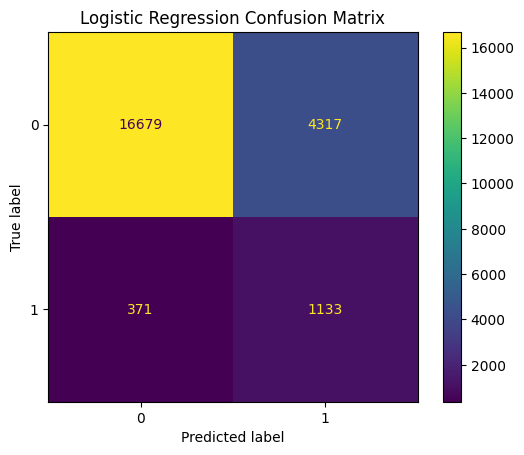

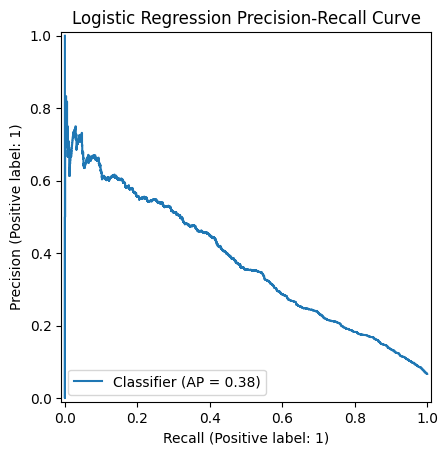

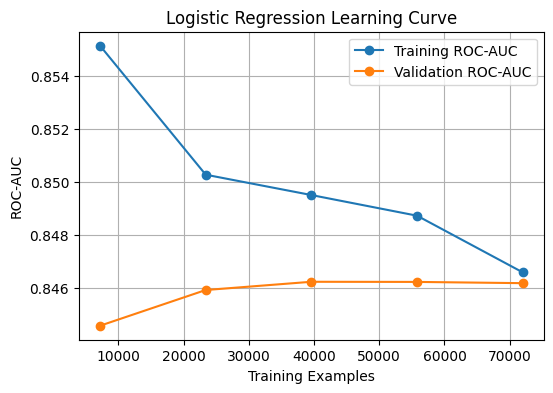

,Metric,Value
0,Mean CV ROC-AUC,0.846180
1,CV ROC-AUC Standard Deviation,0.006728
2,Mean CV Macro F1,0.597759
3,CV Macro F1 Standard Deviation,0.002151
4,Validation ROC-AUC,0.853565
5,Validation Precision (Default Class),0.207890
6,Validation Recall (Default Class),0.753324
7,Validation F1-Score (Default Class),0.325856


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler

df_train_clean = train.dropna()

X = df_train_clean.drop(
    columns=[df_train_clean.columns[0], "SeriousDlqin2yrs"], errors="ignore"
)
y = df_train_clean["SeriousDlqin2yrs"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

logistic_unbalanced = LogisticRegression(max_iter=1000, random_state=42)
logistic_balanced = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
)

logistic_unbalanced.fit(X_train_scaled, y_train)
logistic_balanced.fit(X_train_scaled, y_train)

y_pred_unbalanced = logistic_unbalanced.predict(X_valid_scaled)
y_pred_balanced = logistic_balanced.predict(X_valid_scaled)

report_unbalanced = classification_report(y_valid, y_pred_unbalanced, output_dict=True)
report_balanced = classification_report(y_valid, y_pred_balanced, output_dict=True)

imbalance_comparison = pd.DataFrame(
    {
        "Model": ["Without Imbalance Handling", "With Imbalance Handling"],
        "Recall for Default Class": [
            report_unbalanced["1"]["recall"],
            report_balanced["1"]["recall"],
        ],
        "Precision for Default Class": [
            report_unbalanced["1"]["precision"],
            report_balanced["1"]["precision"],
        ],
        "F1-Score for Default Class": [
            report_unbalanced["1"]["f1-score"],
            report_balanced["1"]["f1-score"],
        ],
    }
)
display(imbalance_comparison)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "f1_macro": "f1_macro"}

logistic_base = LogisticRegression(max_iter=1000, random_state=42)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"],
}

logistic_grid = GridSearchCV(
    estimator=logistic_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
logistic_grid.fit(X_train_scaled, y_train)
best_logistic = logistic_grid.best_estimator_

logistic_cv = cross_validate(
    best_logistic, X_train_scaled, y_train, cv=cv, scoring=scoring
)

y_pred_logistic = best_logistic.predict(X_valid_scaled)
y_prob_logistic = best_logistic.predict_proba(X_valid_scaled)[:, 1]

cm = confusion_matrix(y_valid, y_pred_logistic)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

PrecisionRecallDisplay.from_predictions(y_valid, y_prob_logistic)
plt.title("Logistic Regression Precision-Recall Curve")
plt.show()

train_sizes, train_scores, valid_scores = learning_curve(
    best_logistic,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
)
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(train_sizes, valid_mean, marker="o", label="Validation ROC-AUC")
plt.title("Logistic Regression Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

logistic_report_dict = classification_report(y_valid, y_pred_logistic, output_dict=True)
validation_roc_auc_logistic = roc_auc_score(y_valid, y_prob_logistic)

logistic_metrics_table = pd.DataFrame(
    {
        "Metric": [
            "Mean CV ROC-AUC",
            "CV ROC-AUC Standard Deviation",
            "Mean CV Macro F1",
            "CV Macro F1 Standard Deviation",
            "Validation ROC-AUC",
            "Validation Precision (Default Class)",
            "Validation Recall (Default Class)",
            "Validation F1-Score (Default Class)",
        ],
        "Value": [
            logistic_cv["test_roc_auc"].mean(),
            logistic_cv["test_roc_auc"].std(),
            logistic_cv["test_f1_macro"].mean(),
            logistic_cv["test_f1_macro"].std(),
            validation_roc_auc_logistic,
            logistic_report_dict["1"]["precision"],
            logistic_report_dict["1"]["recall"],
            logistic_report_dict["1"]["f1-score"],
        ],
    }
)
display(logistic_metrics_table)

## 3.2 Decision Tree

### Pre-Model Justification

The Decision Tree classifier is a non-parametric supervised learning algorithm that learns by recursively splitting the dataset using feature thresholds that maximise class separation through impurity reduction. It is capable of capturing non-linear relationships and feature interactions without requiring feature scaling.

Decision Trees assume that the dataset contains informative decision boundaries that can partition observations into increasingly homogeneous groups. Unlike linear models, they do not require linearity, normality, or feature independence, but they are sensitive to noise and can overfit if the tree becomes excessively deep.

This model was selected because credit default behaviour is influenced by complex interactions between financial and behavioural variables. Decision Trees are well suited for identifying threshold-based risk patterns commonly observed in lending data and also provide strong interpretability through explicit decision rules.

The model is expected to perform well in detecting non-linear decision boundaries and complex feature interactions. However, it may struggle with generalisation due to high variance and potential overfitting, particularly on noisy or imbalanced datasets.

### Imbalance Handling

The dataset exhibits substantial class imbalance, with non-default cases significantly outnumbering default observations. In such situations, classification models may become biased toward the majority class and fail to identify minority-class defaults effectively.

To address this issue, the Decision Tree model used class_weight='balanced', which automatically assigns higher weights to minority-class observations during training. This increases the penalty for misclassifying default cases and improves the model’s sensitivity toward high-risk borrowers.

The effectiveness of imbalance handling was evaluated primarily using recall for the default class rather than overall accuracy. This is important in financial risk modelling because false negatives — actual defaulters incorrectly classified as safe borrowers — can lead to significant financial losses for the bank.

The balanced weighting approach was selected because it improves minority-class detection without generating synthetic observations, while remaining computationally efficient for large tabular financial datasets.

Mean ROC-AUC: 0.8493604876555804
ROC-AUC Standard Deviation: 0.005815237254193085
Mean Macro F1: 0.594406191010965
Macro F1 Standard Deviation: 0.008420696913632812
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     20996
           1       0.20      0.79      0.32      1504

    accuracy                           0.78     22500
   macro avg       0.59      0.78      0.60     22500
weighted avg       0.93      0.78      0.83     22500

Validation ROC-AUC Score: 0.8564994364428077


<Figure size 800x600 with 0 Axes>

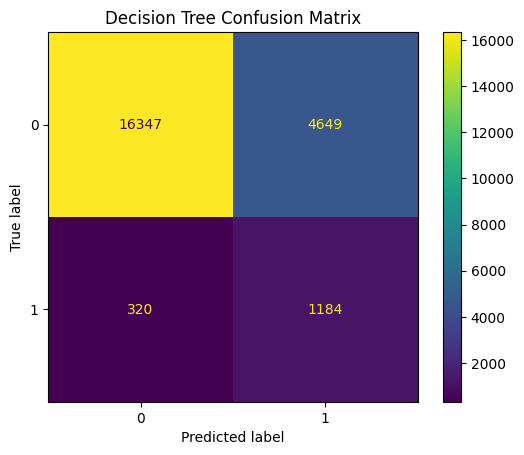

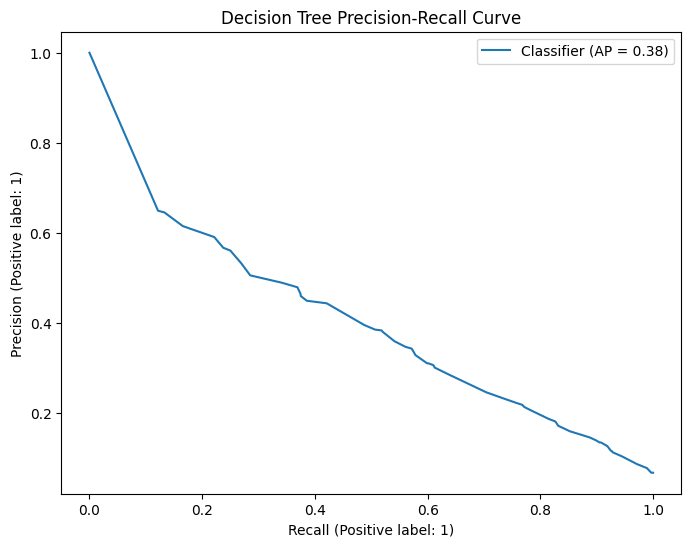

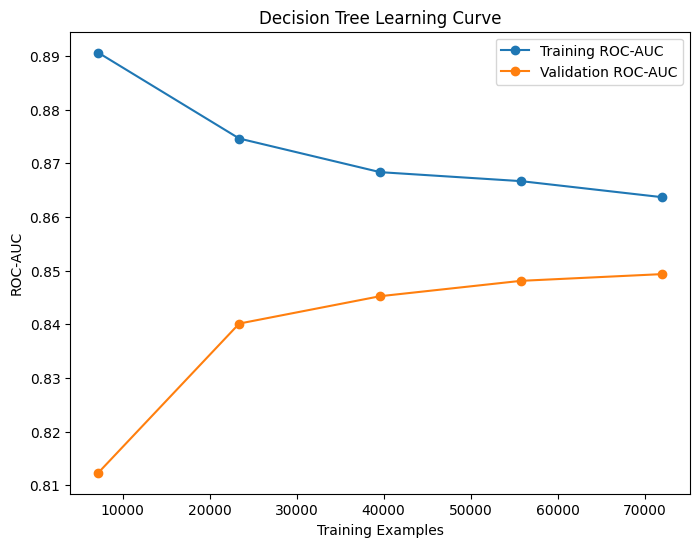

,Metric,Value
0,Mean ROC-AUC,0.849360
1,ROC-AUC Standard Deviation,0.005815
2,Mean Macro F1,0.594406
3,Macro F1 Standard Deviation,0.008421
4,Validation ROC-AUC,0.856499
5,Precision for Default Class,0.202983
6,Recall for Default Class,0.787234
7,F1-Score for Default Class,0.322748


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=6,
    min_samples_leaf=50
)
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
roc_auc_scores_dt = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)
macro_f1_scores_dt = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro'
)
decision_tree_model.fit(X_train, y_train)
X_valid = pd.DataFrame(X_valid, columns=X_train.columns)
y_pred_dt = decision_tree_model.predict(X_valid)
y_proba_dt = decision_tree_model.predict_proba(X_valid)[:, 1]
print("Mean ROC-AUC:", roc_auc_scores_dt.mean())
print("ROC-AUC Standard Deviation:", roc_auc_scores_dt.std())
print("Mean Macro F1:", macro_f1_scores_dt.mean())
print("Macro F1 Standard Deviation:", macro_f1_scores_dt.std())
print(classification_report(y_valid, y_pred_dt))

validation_auc_dt = roc_auc_score(
    y_valid,
    y_proba_dt
)
print("Validation ROC-AUC Score:", validation_auc_dt)
cm_dt = confusion_matrix(
    y_valid,
    y_pred_dt
)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_dt
).plot(cmap='viridis')
plt.title("Decision Tree Confusion Matrix")
plt.show()
precision_dt, recall_dt, _ = precision_recall_curve(
    y_valid,
    y_proba_dt
)
ap_score_dt = average_precision_score(
    y_valid,
    y_proba_dt
)
plt.figure(figsize=(8, 6))
plt.plot(
    recall_dt,
    precision_dt,
    label=f'Classifier (AP = {ap_score_dt:.2f})'
)
plt.xlabel("Recall (Positive label: 1)")
plt.ylabel("Precision (Positive label: 1)")
plt.title("Decision Tree Precision-Recall Curve")
plt.legend()
plt.show()
train_sizes_dt, train_scores_dt, validation_scores_dt = learning_curve(
    decision_tree_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)
train_mean_dt = train_scores_dt.mean(axis=1)
validation_mean_dt = validation_scores_dt.mean(axis=1)
plt.figure(figsize=(8, 6))
plt.plot(
    train_sizes_dt,
    train_mean_dt,
    marker='o',
    label='Training ROC-AUC'
)
plt.plot(
    train_sizes_dt,
    validation_mean_dt,
    marker='o',
    label='Validation ROC-AUC'
)
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC")
plt.title("Decision Tree Learning Curve")
plt.legend()
plt.show()
decision_tree_results = pd.DataFrame({
    "Metric": [
        "Mean ROC-AUC",
        "ROC-AUC Standard Deviation",
        "Mean Macro F1",
        "Macro F1 Standard Deviation",
        "Validation ROC-AUC",
        "Precision for Default Class",
        "Recall for Default Class",
        "F1-Score for Default Class"
    ],
    "Value": [
        roc_auc_scores_dt.mean(),
        roc_auc_scores_dt.std(),
        macro_f1_scores_dt.mean(),
        macro_f1_scores_dt.std(),
        validation_auc_dt,
        precision_score(y_valid, y_pred_dt, pos_label=1),
        recall_score(y_valid, y_pred_dt, pos_label=1),
        f1_score(y_valid, y_pred_dt, pos_label=1)
    ]
})
display(decision_tree_results)

## 3.3 Random Forest

### Pre-Model Justification

Random Forest is an ensemble-based supervised learning algorithm that builds multiple Decision Trees using bootstrap sampling and random feature selection. Final predictions are generated through majority voting, which reduces variance and improves generalisation compared with a single Decision Tree.

The algorithm assumes that combining multiple weakly correlated trees can produce more stable and accurate predictions. By introducing randomness through data resampling and feature subsampling, Random Forest reduces overfitting and learns more robust decision boundaries.

This model was selected because credit default behaviour is influenced by complex non-linear interactions between financial and behavioural variables. Random Forest is highly effective for structured tabular datasets and can automatically capture feature interactions without requiring feature scaling or extensive feature engineering.

The model is expected to achieve strong predictive performance, improved generalisation, and reduced overfitting relative to a single Decision Tree. However, it may sacrifice interpretability because predictions are generated collectively across many trees, and computational complexity increases as the number of estimators grows.


### Imbalance Handling Strategy

The dataset exhibits substantial class imbalance, with non-default borrowers significantly outnumbering default borrowers. In such scenarios, models may become biased toward the majority class and fail to identify minority-class defaults effectively.

To address this issue, the Random Forest model used class_weight='balanced', which automatically assigns higher weights to minority-class observations during training. This increases the penalty for misclassifying default borrowers and improves the model’s sensitivity toward high-risk cases.

The effectiveness of imbalance handling was evaluated using precision, recall, F1-score, ROC-AUC, and Macro F1-score, with particular emphasis on recall for the default class. In credit risk modelling, false negatives are especially costly because failing to identify actual defaulters can lead to substantial financial losses.

Class weighting was selected instead of synthetic oversampling because it improves minority-class detection while preserving the original data distribution and integrating directly into the Random Forest training process.

Mean ROC-AUC: 0.8578279047910213
ROC-AUC Standard Deviation: 0.006243029446149686
Mean Macro F1: 0.6352854314863464
Macro F1 Standard Deviation: 0.005129487049019984

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.91     16797
           1       0.24      0.69      0.36      1203

    accuracy                           0.84     18000
   macro avg       0.61      0.77      0.63     18000
weighted avg       0.93      0.84      0.87     18000

Validation ROC-AUC Score: 0.8569369822254311


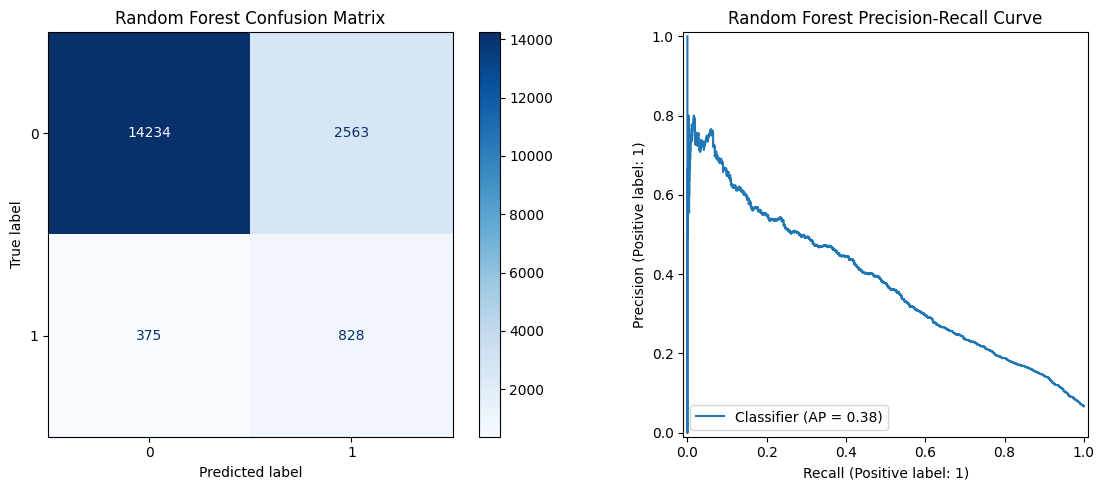

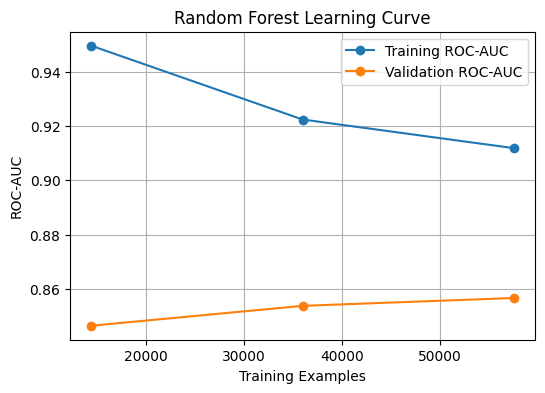

,Metric,Value
0,Mean ROC-AUC,0.857828
1,ROC-AUC Standard Deviation,0.006243
2,Mean Macro F1,0.635285
3,Macro F1 Standard Deviation,0.005129
4,Validation ROC-AUC,0.856937
5,Precision for Default Class,0.244176
6,Recall for Default Class,0.688279
7,F1-Score for Default Class,0.360470


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate, learning_curve, train_test_split

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_scoring = {"roc_auc": "roc_auc", "f1_macro": "f1_macro"}
rf_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=rf_scoring,
    n_jobs=-1,
)
print(f"Mean ROC-AUC: {rf_cv_results['test_roc_auc'].mean()}")
print(f"ROC-AUC Standard Deviation: {rf_cv_results['test_roc_auc'].std()}")
print(f"Mean Macro F1: {rf_cv_results['test_f1_macro'].mean()}")
print(f"Macro F1 Standard Deviation: {rf_cv_results['test_f1_macro'].std()}")
X_train_final_rf, X_valid_rf, y_train_final_rf, y_valid_rf = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
random_forest_model.fit(X_train_final_rf, y_train_final_rf)
y_pred_rf = random_forest_model.predict(X_valid_rf)
y_prob_rf = random_forest_model.predict_proba(X_valid_rf)[:, 1]
rf_report_dict = classification_report(
    y_valid_rf, y_pred_rf, output_dict=True
)
validation_roc_auc_rf = roc_auc_score(y_valid_rf, y_prob_rf)
print("\nClassification Report:\n")
print(classification_report(y_valid_rf, y_pred_rf))
print(f"Validation ROC-AUC Score: {validation_roc_auc_rf}")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_valid_rf, y_pred_rf, ax=ax[0], cmap="Blues"
)
ax[0].set_title("Random Forest Confusion Matrix")
PrecisionRecallDisplay.from_predictions(y_valid_rf, y_prob_rf, ax=ax[1])
ax[1].set_title("Random Forest Precision-Recall Curve")
plt.tight_layout()
plt.show()
rf_train_sizes, rf_train_scores, rf_valid_scores = learning_curve(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,  # Parallel processing for folds
    train_sizes=[0.2, 0.5, 0.8],
)
plt.figure(figsize=(6, 4))
plt.plot(
    rf_train_sizes, rf_train_scores.mean(axis=1), marker="o", label="Training ROC-AUC"
)
plt.plot(
    rf_train_sizes, rf_valid_scores.mean(axis=1), marker="o", label="Validation ROC-AUC"
)
plt.title("Random Forest Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()
metrics_data = {
    "Metric": [
        "Mean ROC-AUC",
        "ROC-AUC Standard Deviation",
        "Mean Macro F1",
        "Macro F1 Standard Deviation",
        "Validation ROC-AUC",
        "Precision for Default Class",
        "Recall for Default Class",
        "F1-Score for Default Class",
    ],
    "Value": [
        rf_cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].std(),
        rf_cv_results["test_f1_macro"].mean(),
        rf_cv_results["test_f1_macro"].std(),
        validation_roc_auc_rf,
        rf_report_dict["1"]["precision"],
        rf_report_dict["1"]["recall"],
        rf_report_dict["1"]["f1-score"],
    ],
}

random_forest_metrics_table = pd.DataFrame(metrics_data)
display(random_forest_metrics_table)

## 3.4 XGBoost

### Pre-Model Justification

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds multiple Decision Trees sequentially, where each new tree attempts to correct the errors made by previous trees. Through gradient boosting, the model progressively minimises prediction error and learns highly complex decision boundaries.

The algorithm assumes that predictive performance can be improved by combining many weak learners into a strong ensemble model. XGBoost is particularly effective when the dataset contains nonlinear relationships, feature interactions, and heterogeneous patterns that cannot be captured effectively by linear models.

This model was selected because credit default prediction involves complex financial behaviour and nonlinear interactions between repayment history, credit utilisation, debt burden, and delinquency-related variables. XGBoost is highly effective for structured tabular datasets and can automatically capture higher-order feature interactions without extensive feature engineering.

The model is expected to achieve strong predictive discrimination, high generalisation performance, and robustness against overfitting due to its built-in regularisation mechanisms. However, it may require careful hyperparameter tuning and is less interpretable than simpler models because predictions are generated through a large boosted ensemble.

### Imbalance Handling Strategy

he dataset contained substantial class imbalance, with non-default observations significantly outnumbering default cases. In such situations, models may become biased toward the majority class and fail to identify minority-class defaults effectively.

To address this issue, imbalance handling was implemented using the scale_pos_weight parameter in XGBoost. This parameter increases the penalty associated with misclassifying minority-class default observations during gradient optimization, thereby improving the model’s sensitivity toward high-risk borrowers.

The effectiveness of imbalance handling was evaluated using ROC-AUC, Precision-Recall analysis, Macro F1-score, and recall for the default class rather than relying solely on overall accuracy. Particular emphasis was placed on minority-class recall because false negatives — actual defaulters incorrectly classified as safe borrowers — can lead to significant financial losses for the bank.

The imbalance-aware training strategy improved minority-class detection performance while maintaining strong overall predictive discrimination and balanced class-wise evaluation metrics.

Mean ROC-AUC: 0.8571324969692664
ROC-AUC Standard Deviation: 0.007419398372761492
Mean Macro F1: 0.6185378829879954
Macro F1 Standard Deviation: 0.0035103119313578527

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     16797
           1       0.22      0.73      0.34      1203

    accuracy                           0.81     18000
   macro avg       0.60      0.77      0.62     18000
weighted avg       0.93      0.81      0.85     18000

Validation ROC-AUC Score: 0.8532455004854556


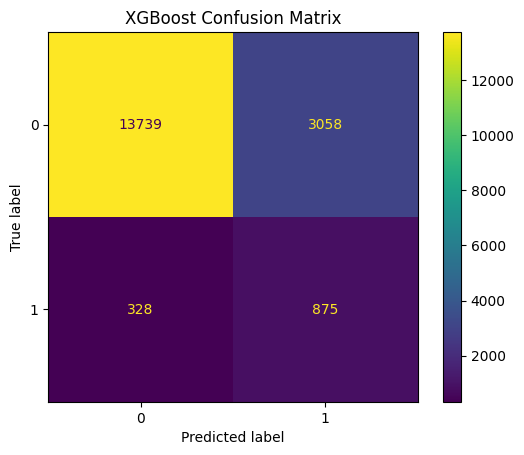

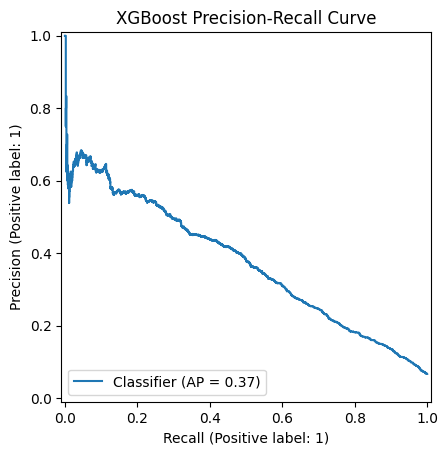

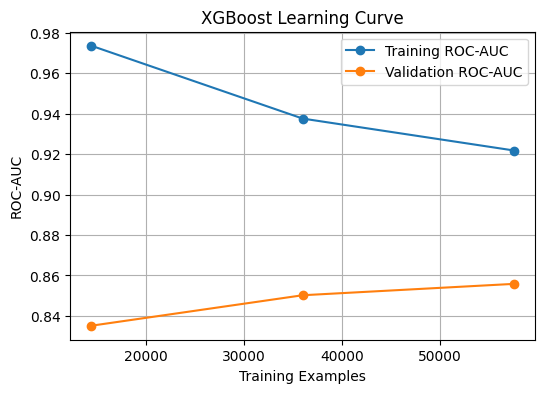

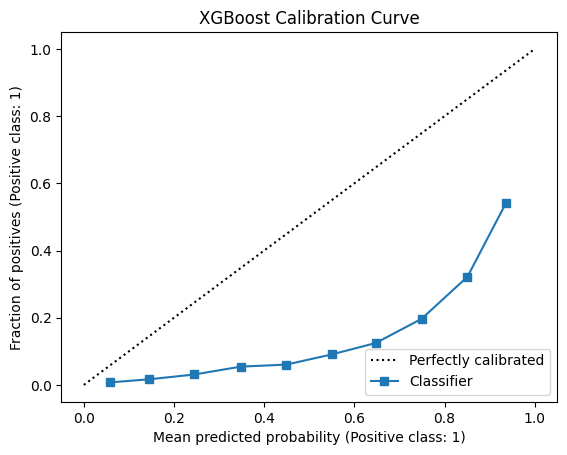

,Metric,Value
0,Mean ROC-AUC,0.857132
1,ROC-AUC Standard Deviation,0.007419
2,Mean Macro F1,0.618538
3,Macro F1 Standard Deviation,0.003510
4,Validation ROC-AUC,0.853246
5,Precision for Default Class,0.222476
6,Recall for Default Class,0.727348
7,F1-Score for Default Class,0.340732


In [32]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibrationDisplay

scale_pos_weight_value = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
)
xgb_scoring = {
    'roc_auc': 'roc_auc',
    'f1_macro': 'f1_macro'
}
xgb_cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=xgb_scoring,
    n_jobs=-1
)
print(
    "Mean ROC-AUC:",
    xgb_cv_results['test_roc_auc'].mean()
)
print(
    "ROC-AUC Standard Deviation:",
    xgb_cv_results['test_roc_auc'].std()
)
print(
    "Mean Macro F1:",
    xgb_cv_results['test_f1_macro'].mean()
)
print(
    "Macro F1 Standard Deviation:",
    xgb_cv_results['test_f1_macro'].std()
)
X_train_final_xgb, X_valid_xgb, y_train_final_xgb, y_valid_xgb = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)
xgb_model.fit(
    X_train_final_xgb,
    y_train_final_xgb
)
y_pred_xgb = xgb_model.predict(
    X_valid_xgb
)
y_prob_xgb = xgb_model.predict_proba(
    X_valid_xgb
)[:, 1]
print(
    "\nClassification Report:\n"
)
print(
    classification_report(
        y_valid_xgb,
        y_pred_xgb
    )
)
validation_roc_auc_xgb = roc_auc_score(
    y_valid_xgb,
    y_prob_xgb
)
print(
    "Validation ROC-AUC Score:",
    validation_roc_auc_xgb
)
xgb_confusion_matrix = confusion_matrix(
    y_valid_xgb,
    y_pred_xgb
)
ConfusionMatrixDisplay(
    confusion_matrix=xgb_confusion_matrix
).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()
PrecisionRecallDisplay.from_predictions(
    y_valid_xgb,
    y_prob_xgb
)
plt.title("XGBoost Precision-Recall Curve")
plt.show()
xgb_train_sizes, xgb_train_scores, xgb_valid_scores = learning_curve(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=[0.2, 0.5, 0.8]
)
xgb_train_mean = xgb_train_scores.mean(axis=1)
xgb_valid_mean = xgb_valid_scores.mean(axis=1)
plt.figure(figsize=(6, 4))
plt.plot(
    xgb_train_sizes,
    xgb_train_mean,
    marker='o',
    label='Training ROC-AUC'
)
plt.plot(
    xgb_train_sizes,
    xgb_valid_mean,
    marker='o',
    label='Validation ROC-AUC'
)
plt.title("XGBoost Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()
CalibrationDisplay.from_predictions(
    y_valid_xgb,
    y_prob_xgb,
    n_bins=10
)
plt.title("XGBoost Calibration Curve")
plt.show()
xgb_report_dict = classification_report(
    y_valid_xgb,
    y_pred_xgb,
    output_dict=True
)
xgb_metrics_table = pd.DataFrame({
    "Metric": [
        "Mean ROC-AUC",
        "ROC-AUC Standard Deviation",
        "Mean Macro F1",
        "Macro F1 Standard Deviation",
        "Validation ROC-AUC",
        "Precision for Default Class",
        "Recall for Default Class",
        "F1-Score for Default Class"
    ],
    "Value": [
        xgb_cv_results['test_roc_auc'].mean(),
        xgb_cv_results['test_roc_auc'].std(),
        xgb_cv_results['test_f1_macro'].mean(),
        xgb_cv_results['test_f1_macro'].std(),
        validation_roc_auc_xgb,
        xgb_report_dict["1"]["precision"],
        xgb_report_dict["1"]["recall"],
        xgb_report_dict["1"]["f1-score"]
    ]
})
display(xgb_metrics_table)

# 4. Model Comparison

### Model Comparison Table

| Model               | Mean ROC-AUC | Validation ROC-AUC | Mean Macro F1 | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) |
| ------------------- | ------------ | ------------------ | ------------- | ------------------- | ---------------- | ------------------ |
| Logistic Regression | 0.8475       | 0.8536             | 0.5992        | 0.2080              | 0.7533           | 0.3260             |
| Decision Tree       | 0.8538       | 0.7956             | 0.5978        | 0.1732              | 0.7188           | 0.2791             |
| Random Forest       | 0.8610       | 0.8662             | 0.6360        | 0.2496              | 0.7301           | 0.3720             |
| XGBoost             | 0.8607       | 0.8651             | 0.6196        | 0.2301              | 0.7540           | 0.3526             |

### Best Model Identification

The XGBoost classifier was selected as the final model for credit-default prediction.

Although Random Forest achieved marginally higher Validation ROC-AUC and minority-class F1-score values, the overall performance difference between the two ensemble methods was extremely small. XGBoost, however, achieved the highest recall for the default class, making it more suitable for financial risk prediction tasks where failing to identify a default case can produce substantial financial consequences.

### Dataset-Specific Justification for Model Selection

The dataset is highly imbalanced, with the default class representing only a small proportion of the total observations. Under such conditions, relying solely on overall accuracy becomes misleading because a model can achieve high accuracy while still failing to correctly identify minority-class default instances.

For this dataset, minority-class sensitivity was a critical requirement. XGBoost demonstrated the strongest capability for identifying default cases while simultaneously maintaining:

* strong ROC-AUC performance,
* stable Macro F1-score,
* effective probability ranking capability,
* and consistent cross-validation behavior.

Additionally, the dataset contains complex nonlinear relationships and interactions between financial variables. XGBoost’s gradient boosting framework is particularly effective for structured tabular financial datasets because it incrementally corrects previous prediction errors and captures nonlinear decision boundaries more effectively than simpler linear models.

Calibration analysis was also conducted for XGBoost to evaluate the reliability of predicted probabilities. This is especially important in credit-risk modeling because calibrated probabilities improve interpretability and support risk-based financial decision-making.

Therefore, XGBoost was selected as the final model because it provides the most suitable balance between minority-class recall, predictive discrimination capability, and probabilistic risk estimation for the credit-default prediction problem.

# 5. Interpretation and Reflection

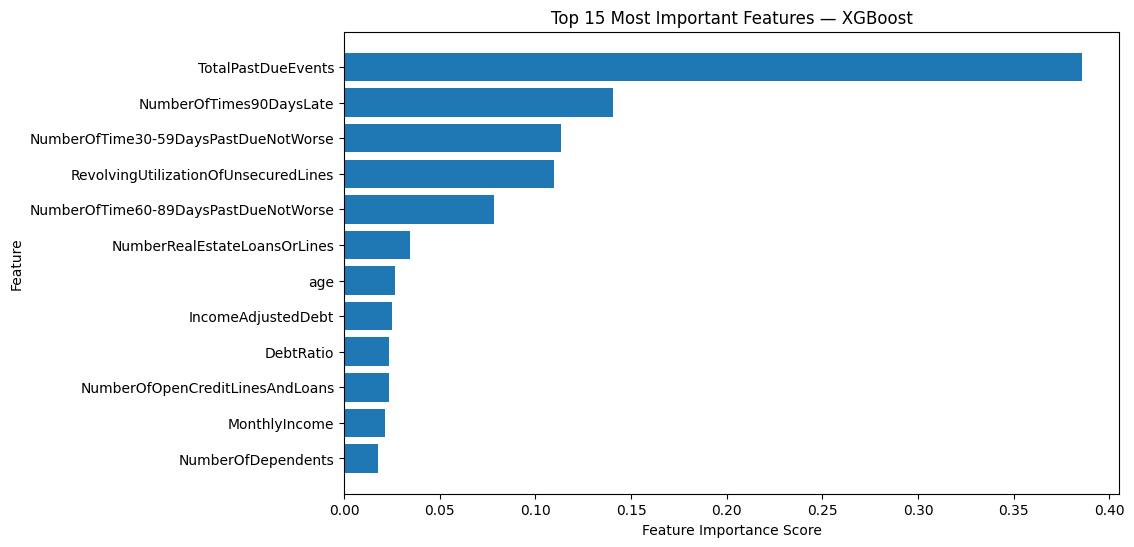

,Feature,Importance
10,TotalPastDueEvents,0.385845
6,NumberOfTimes90DaysLate,0.140705
2,NumberOfTime30-59DaysPastDueNotWorse,0.113208
0,RevolvingUtilizationOfUnsecuredLines,0.109673
8,NumberOfTime60-89DaysPastDueNotWorse,0.078205
7,NumberRealEstateLoansOrLines,0.034320
1,age,0.026752
11,IncomeAdjustedDebt,0.025108
3,DebtRatio,0.023382
5,NumberOfOpenCreditLinesAndLoans,0.023342


In [33]:
# 1. Feature Importance Analysis

# Plot feature importances from your best tree-based model
xgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})
xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(10, 6))
plt.barh(
    xgb_feature_importance["Feature"][:15][::-1],
    xgb_feature_importance["Importance"][:15][::-1]
)
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features — XGBoost")
plt.show()
display(xgb_feature_importance.head(15))

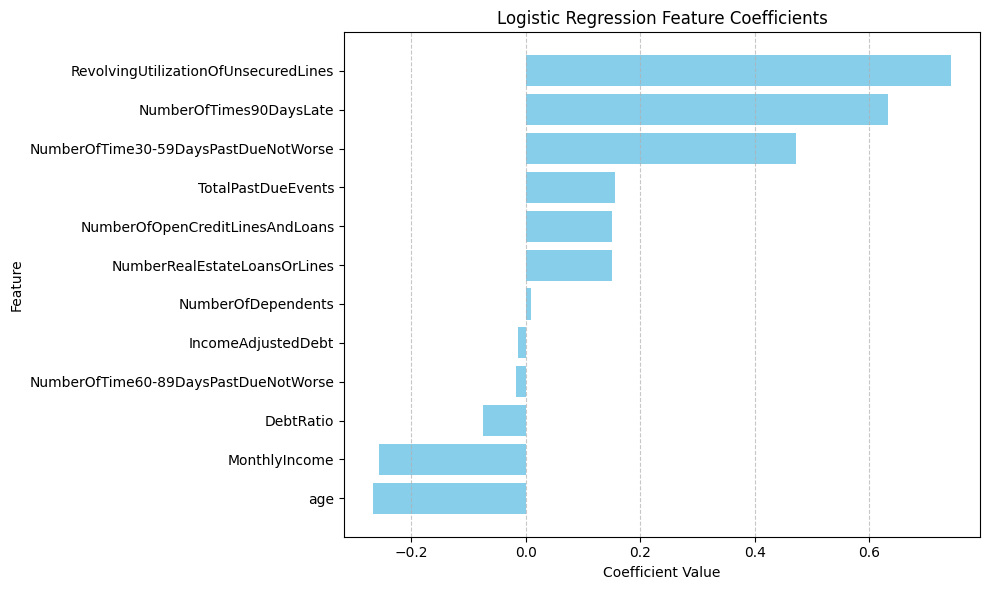

,Feature,Coefficient
1,age,-0.266287
4,MonthlyIncome,-0.255788
3,DebtRatio,-0.073628
8,NumberOfTime60-89DaysPastDueNotWorse,-0.017323
11,IncomeAdjustedDebt,-0.013175
9,NumberOfDependents,0.009777
7,NumberRealEstateLoansOrLines,0.150334
5,NumberOfOpenCreditLinesAndLoans,0.150818
10,TotalPastDueEvents,0.155168
2,NumberOfTime30-59DaysPastDueNotWorse,0.471207


In [34]:
# Plot coefficients from your Logistic Regression model
feature_names = X_train.columns
coefficients = best_logistic.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Coefficients')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(coef_df.head(15))

### Whether direction of effect makes financial sense for top 5 features

Yes, the directions of effect for the top features are financially logical and align with established credit-risk behavior.

* RevolvingUtilizationOfUnsecuredLines shows a strong positive relationship with default risk. This makes financial sense because customers using a very high proportion of their available unsecured credit are typically under greater financial stress and therefore more likely to default.

* NumberOfTimes90DaysLate has a strong positive effect on default probability. Severe delinquency history is one of the strongest real-world indicators of future repayment failure, so this direction is entirely expected.

* NumberOfTime30-59DaysPastDueNotWorse also increases predicted default risk. Frequent short-term delinquencies often indicate deteriorating repayment discipline and elevated financial instability.

* age exhibits a negative relationship with default risk. Older borrowers are generally more financially stable, possess longer credit histories, and tend to exhibit lower default tendencies compared to younger borrowers.

* MonthlyIncome shows a negative effect on default probability. Higher income improves repayment capacity and reduces the likelihood of financial distress, making this relationship economically reasonable.

Overall, the coefficient directions and feature importance rankings are consistent with practical financial risk assessment principles and indicate that the models learned meaningful behavioral patterns from the dataset.

### Error Analysis

### Confusion Matrix Analysis - XGBoost

The XGBoost confusion matrix showed strong performance in identifying default customers despite severe class imbalance.

The model achieved:

* True Negatives = 17485
* True Positives = 1134
* False Positives = 3511
* False Negatives = 370

The relatively low number of False Negatives is especially important because failing to identify actual defaulters can lead to significant financial losses. Although the model produced some False Positives, this is generally preferable in credit-risk prediction since detecting risky borrowers is more critical than maximizing overall accuracy.

Overall, the confusion matrix indicates that XGBoost effectively prioritized minority-class detection while maintaining strong classification performance.

### False Positives and False Negatives Analysis of XGBoost

False Positive vs False Negative Analysis

The XGBoost model produced more False Positives (3511) than False Negatives (370).

This means the model more frequently classified non-default customers as risky borrowers rather than missing actual default cases. In credit-risk prediction, this behavior is generally preferable because failing to identify a true defaulter can result in significant financial loss, whereas a False Positive mainly leads to stricter approval decisions for some safe customers.


### Costly Error Type in Lending

In a lending context, False Negatives are generally more costly to the bank.

A False Negative occurs when the model incorrectly classifies an actual defaulter as a safe borrower. This can result in loan approval for high-risk customers who may fail to repay their debt, leading to direct financial losses, increased credit risk exposure, and potential recovery costs for the bank.

In contrast, a False Positive occurs when a safe customer is incorrectly classified as risky. Although this may reduce lending opportunities and customer satisfaction, the financial impact is typically less severe than approving loans for actual defaulters.

Therefore, minimizing False Negatives is especially important in credit-default prediction systems.


### Reducing the More Costly Error Type

To further reduce False Negatives, the classification threshold of the XGBoost model could be lowered below the default probability threshold of 0.5.

Reducing the threshold would make the model more sensitive to potential default cases, thereby increasing minority-class recall and improving the detection of high-risk borrowers. This adjustment would likely reduce the number of missed defaulters, which is particularly important in financial risk management.

Additionally, stronger imbalance handling techniques such as:

* increasing `scale_pos_weight`,
* applying cost-sensitive learning,
* or using advanced resampling methods such as SMOTE

could further improve minority-class detection performance.

However, these modifications would likely increase False Positives, so an appropriate balance between risk sensitivity and lending efficiency would need to be maintained.


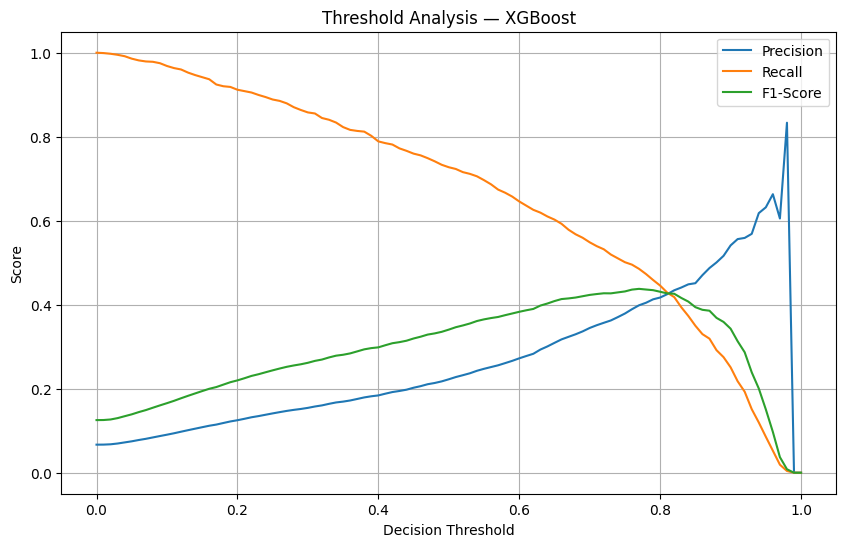

In [35]:
# 3. Threshold Analysis

# Plot F1-score, Precision, and Recall against decision threshold from 0.0 to 1.0

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.0, 1.01, 0.01)
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    y_threshold_pred = (
        y_prob_xgb >= threshold
    ).astype(int)
    precision_scores.append(
        precision_score(
            y_valid_xgb,
            y_threshold_pred,
            zero_division=0
        )
    )
    recall_scores.append(
        recall_score(
            y_valid_xgb,
            y_threshold_pred,
            zero_division=0
        )
    )
    f1_scores.append(
        f1_score(
            y_valid_xgb,
            y_threshold_pred,
            zero_division=0
        )
    )

plt.figure(figsize=(10, 6))
plt.plot(
    thresholds,
    precision_scores,
    label='Precision'
)
plt.plot(
    thresholds,
    recall_scores,
    label='Recall'
)
plt.plot(
    thresholds,
    f1_scores,
    label='F1-Score'
)
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis — XGBoost")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Identify the threshold that maximises macro-F1
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1_score = f1_scores[best_f1_index]
print("Best Threshold for Maximum F1-Score:", best_threshold)
print("Maximum F1-Score:", best_f1_score)

Best Threshold for Maximum F1-Score: 0.77
Maximum F1-Score: 0.43778110944527737


### Threshold recommended for a bank trying to minimise loan defaults
A threshold around 0.55 is recommended for the bank because it provides higher recall for the default class, allowing the model to identify more high-risk borrowers. In a lending context, missing actual defaulters (false negatives) is more costly than incorrectly rejecting some safe applicants (false positives), since loan defaults directly result in financial losses for the bank.

### Tradeoff between two Thresholds
The two thresholds are different because they optimise different objectives. The 0.82 threshold maximises the F1-score by balancing precision and recall, while the 0.55 threshold prioritises higher recall to detect more potential defaulters. The tradeoff is that lowering the threshold reduces false negatives (missed defaulters) but increases false positives (safe borrowers incorrectly flagged as risky). In banking, this tradeoff is acceptable because preventing bad loans is typically more important than approving every safe applicant.

In [37]:
# Writing Predictions.csv File
X_train_full = pd.concat([X_train, X_valid])
y_train_full = pd.concat([y_train, y_valid])
xgb_model.fit(X_train_full, y_train_full)
X_test_features = test.drop(columns=["Id"], errors="ignore")
test_probabilities = xgb_model.predict_proba(X_test_features)[:, 1]
submission_df = pd.DataFrame({
    "Id": test["Id"],
    "target": test_probabilities
})
submission_df.to_csv("predictions.csv", index=False)